# Intro

## Global parameters

In [1]:
MAX_TIME_HOURS=1
ALPHA=0.01
_PVAL_FLOOR=10**-6

## Modules

### Standard

In [2]:
import os, pickle, platform, sys
import numpy as np

In [3]:
from collections import defaultdict

In [4]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

In [6]:
from scipy.stats import spearmanr

In [7]:
from tqdm.notebook import tqdm, trange

In [8]:
import datetime as dt

In [9]:
from bowtie import edges2bowtie

### Home made

In [10]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")

sys.path.insert(0, HOME)

Stella!


In [11]:
from auxiliary_functions import el2ks

In [12]:
from sam_bowtie import block_and_fluxes as bnf

In [13]:
from bowtie_plot_functions import plot_bowtie_blocks, plot_bowtie_fluxes, _add_colorbar
from bowtie_plot_functions import _fdr as fdr

## Load data

In [54]:
DATA_FOLDER=HOME+'dati_elezioni/'
TEST_FOLDER=HOME+'tests/'
PVALUE_FOLDER=HOME+'pvalues/'
GUARINO_FOLDER=HOME+'guarino_files/'
BIPARTITE_FOLDER=HOME+'BiDCM2/'
PLOT_FOLDER=HOME+'plots/'

# Looking into the abyss

In [17]:
guarino_files=[file for file in os.listdir(GUARINO_FOLDER) if not file.startswith('.')]
guarino_files.sort()
guarino_files

['all_dico_labels.txt',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'crisi_dico_labels.pickle',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'ita_elections_dico_labels.pickle',
 'quirinale_dico_0_bowtie_sizes.csv',
 'quirinale_dico_1_bowtie_sizes.csv',
 'quirinale_dico_2_bowtie_sizes.csv',
 'quirinale_dico_3_bowtie_sizes.csv',
 'quirinale_dico_4_bowtie_sizes.csv',
 'quirinale_dico_5_bowtie_sizes.csv',
 'quirinale_dico_6_bowtie_sizes.csv',
 'quirinale_dico_labels.pickle']

In [18]:
bipartite_files=[file for file in os.listdir(BIPARTITE_FOLDER) if not file.startswith('.')]
bipartite_files.sort()
bipartite_files

['crisi_dico_0_bowtie_flows.csv',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_flows.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_flows.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_flows.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_flows.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_0_bowtie_flows.csv',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_flows.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_flows.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_flows.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_flows.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_flows.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_flows.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'quirinale_dico_0_bowtie_flows.csv',
 'quirinale_dico_0_bowtie_sizes.cs

### Name of the various dicos

In [19]:
guarino_files[0]

'all_dico_labels.txt'

In [20]:
with open(GUARINO_FOLDER+guarino_files[0], 'r') as f:
    cacca=f.readlines()


In [21]:
def parse_dico_names(filepath):
    with open(filepath, 'r') as f:
        lines = [line.strip().split() for line in f]
        # such a command creates a list
        # in which each element is a list of tokens of a line in the file
        # remarkably, there is an empty element
        # before each dataset name
        

    result = {}
    current_key = None

    for tokens in lines:
        if not tokens:
            current_key = None
        elif current_key is None:
            # prima riga non vuota del gruppo: nome del dataset
            current_key = tokens[0]
            result[current_key] = {}
        else:
            # riga tipo ['5:', 'journalists', '&', 'Media']
            idx = int(tokens[0].rstrip(':'))
            label = ' '.join(tokens[1:])
            result[current_key][idx] = label

    return result

In [22]:
cacca=parse_dico_names(GUARINO_FOLDER+guarino_files[0])

In [23]:
cacca

{'quirinale': {5: 'journalists & Media',
  2: 'M5S',
  0: 'journalists & IV & Azione & +Europa & Media',
  4: 'Lega & FDI',
  1: 'PD',
  3: 'Media & journalists',
  6: 'FI'},
 'crisi': {1: 'Lega & FDI & FI',
  2: 'M5S & journalists',
  0: 'journalists & IV & Media & Azione & +Europa',
  4: 'Media & journalists',
  3: 'PD'},
 'ita_elections': {1: 'PD & Media & +Europa & journalists',
  2: 'M5S & Media',
  3: 'journalists & IV & Azione',
  0: 'Lega & FDI & FI',
  4: 'journalists & Media (1)',
  5: 'Media',
  6: 'journalists & Media (2)'}}

# Plots

## Functions

### guarino2dict_blocks

In [24]:
def guarino2dict_blocks(dataset, dico):
    # get the file
    file_name=f'{dataset}_dico_{dico}_bowtie_sizes.csv'
    # load the data
    cacca=np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=int, skip_header=1)
    header = np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=str, max_rows=1)
    header=[str(h) for h in header]
    # load the "monopartite" dict
    block_dict_0, flux_dict_0 = ppmf(dataset, dico)
    
    block_dict_bipartite={}

    guarino_translator={'LSCC':'SCC', 'IN-TENDRILS':'INTENDRILS', 'OUT-TENDRILS':'OUTTENDRILS'}

    for i, name in enumerate(header):
        key=guarino_translator.get(name, name)
        block_dict_bipartite[key] = {}
        block_dict_bipartite[key]['obs']=block_dict_0[key]['obs']
        block_dict_bipartite[key]['sample']=cacca[:,i]
        _ge=np.sum(cacca[:,i]>=block_dict_bipartite[key]['obs'])
        _le=np.sum(cacca[:,i]<=block_dict_bipartite[key]['obs'])
        block_dict_bipartite[key]['p_value']=2*min(_ge, _le)/len(block_dict_bipartite[key]['sample'])
        _median=np.median(block_dict_bipartite[key]['sample'])
        if _median>block_dict_bipartite[key]['obs']:
            block_dict_bipartite[key]['tail']='left'
        else:
            block_dict_bipartite[key]['tail']='right'
    return block_dict_bipartite, block_dict_0, flux_dict_0



### guarino2dict_fluxes

In [55]:
def guarino2dict_fluxes(dataset, dico):
    # get the file
    file_name=f'{dataset}_dico_{dico}_bowtie_flows.csv'
    # load the data
    cacca=np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', skip_header=1)
    cacca=cacca.astype(int)
    header = np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=str, max_rows=1)

    try:
        _, flux_dict_decm = ppmf_decm(dataset, dico)
        decm_pvalues_found=True
    except:
        print(f"DECM p-values not found for dataset {dataset} and dico {dico}. Proceeding with qDECM only.")
        decm_pvalues_found=False
    _, flux_dict_qdecm = ppmf(dataset, dico)

    flux_dict_bipartite=defaultdict(dict)
    guarino_translator={'LSCC':'SCC', 'IN-TENDRILS':'INTENDRILS', 'OUT-TENDRILS':'OUTTENDRILS'}

    

    for i, name in enumerate(header):
        source, target = name.split('->')
        # translate the source and target to match the keys in flux_dict_qdecm
        source = guarino_translator.get(source, source)
        target = guarino_translator.get(target, target)
        key = '->'.join([source, target])

        flux_dict_bipartite[key]['obs']=flux_dict_qdecm[key]['obs']
        flux_dict_bipartite[key]['sample']=cacca[:,i]
        _ge=np.sum(cacca[:,i]>=flux_dict_bipartite[key]['obs'])
        _le=np.sum(cacca[:,i]<=flux_dict_bipartite[key]['obs'])
        flux_dict_bipartite[key]['p_value']=2*min(_ge, _le)/len(flux_dict_bipartite[key]['sample'])
        _median=np.median(flux_dict_bipartite[key]['sample'])
        if _median>flux_dict_bipartite[key]['obs']:
            flux_dict_bipartite[key]['tail']='left'
        else:
            flux_dict_bipartite[key]['tail']='right'
    if decm_pvalues_found:  
        return flux_dict_bipartite, flux_dict_qdecm, flux_dict_decm
    else:
        return flux_dict_bipartite, flux_dict_qdecm, None

### right_tailer

In [34]:
def right_tailer(block_dict):
    right_tailed_dict={}
    for key, item in block_dict.items():
        right_tailed_dict[key] = item
        if item['tail'] == 'right':
            right_tailed_dict[key]['p_value'] /=2
        else:
            right_tailed_dict[key]['p_value']=1.
    return right_tailed_dict


### ppmf: pre-processing my files

In [35]:
def ppmf(dataset, dico):
    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_blocks_1.pkl', 'rb') as f:
        block_dict_1 = pickle.load(f)

    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_fluxes_1.pkl', 'rb') as f:
        flux_dict_1 = pickle.load(f)

    for key, value in block_dict_1.items():
        block_dict_1[key]['mean_sim']=np.mean(value['count_sample'])
        block_dict_1[key]['std_sim']=np.std(value['count_sample'])    
        if np.median(value['count_sample']) > block_dict_1[key]['obs']:
            block_dict_1[key]['tail']='left'
        else:
            block_dict_1[key]['tail']='right'
        
    for key, value in flux_dict_1.items():
        flux_dict_1[key]['mean_sim']=np.mean(value['count_sample'])
        flux_dict_1[key]['std_sim']=np.std(value['count_sample'])    
        if np.median(value['count_sample']) > flux_dict_1[key]['obs']:
            flux_dict_1[key]['tail']='left'
        else:
            flux_dict_1[key]['tail']='right'    

    return block_dict_1, flux_dict_1


In [36]:
def ppmf_decm(dataset, dico):
    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_blocks_decm.pkl', 'rb') as f:
        block_dict_1 = pickle.load(f)

    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_fluxes_decm.pkl', 'rb') as f:
        flux_dict_1 = pickle.load(f)

    for key, value in block_dict_1.items():
        block_dict_1[key]['mean_sim']=np.mean(value['count_sample'])
        block_dict_1[key]['std_sim']=np.std(value['count_sample'])    
        if np.median(value['count_sample']) > block_dict_1[key]['obs']:
            block_dict_1[key]['tail']='left'
        else:
            block_dict_1[key]['tail']='right'
        
    for key, value in flux_dict_1.items():
        flux_dict_1[key]['mean_sim']=np.mean(value['count_sample'])
        flux_dict_1[key]['std_sim']=np.std(value['count_sample'])    
        if np.median(value['count_sample']) > flux_dict_1[key]['obs']:
            flux_dict_1[key]['tail']='left'
        else:
            flux_dict_1[key]['tail']='right'    

    return block_dict_1, flux_dict_1


#### guarino2dict_blocks_DCM

In [37]:
def guarino2dict_blocks_DCM(dataset, dico):
    # get the file
    file_name=f'{dataset}_dico_{dico}_bowtie_sizes.csv'
    # load the data
    cacca=np.genfromtxt(GUARINO_FOLDER+file_name, delimiter=',', dtype=int, skip_header=1)
    header = np.genfromtxt(GUARINO_FOLDER+file_name, delimiter=',', dtype=str, max_rows=1)
    header=[str(h) for h in header]
    # load the "monopartite" dict
    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_blocks_0.pkl', 'rb') as f:
        block_dict_0 = pickle.load(f)

    with open(PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_fluxes_0.pkl', 'rb') as f:
        flux_dict_0 = pickle.load(f)

    block_dict_bipartite={}

    for i, name in enumerate(header):
        if name=='LSCC':
            key='SCC'
        else:
            key=name.replace('-','')
        block_dict_bipartite[key] = {}
        block_dict_bipartite[key]['obs']=block_dict_0[key]['obs']
        block_dict_bipartite[key]['sample']=cacca[:,i]
        _ge=np.sum(cacca[:,i]>=block_dict_bipartite[key]['obs'])
        _le=np.sum(cacca[:,i]<=block_dict_bipartite[key]['obs'])
        block_dict_bipartite[key]['p_value']=2*min(_ge, _le)/len(block_dict_bipartite[key]['sample'])
        _median=np.median(block_dict_bipartite[key]['sample'])
        if _median>block_dict_bipartite[key]['obs']:
            block_dict_bipartite[key]['tail']='left'
        else:
            block_dict_bipartite[key]['tail']='right'
    return block_dict_bipartite, block_dict_0, flux_dict_0



## Italian elections

### Prelude

In [38]:
labels=cacca['ita_elections']
labels = dict(sorted(labels.items()))
labels

{0: 'Lega & FDI & FI',
 1: 'PD & Media & +Europa & journalists',
 2: 'M5S & Media',
 3: 'journalists & IV & Azione',
 4: 'journalists & Media (1)',
 5: 'Media',
 6: 'journalists & Media (2)'}

In [90]:
# statistical significance level for the FDR correction
alpha=0.05

### Right-wing

In [81]:
dataset='ita_elections'
dico=0

In [82]:
blocks=guarino2dict_blocks(dataset, dico)
blocks_dcm=guarino2dict_blocks_DCM(dataset, dico)
fluxes=guarino2dict_fluxes(dataset, dico)

DECM p-values not found for dataset ita_elections and dico 0. Proceeding with qDECM only.


In [83]:
users=0
for key in blocks[0].keys():
    users+=blocks[0][key]['obs']

In [84]:
rts=0
for key in blocks[2].keys():
    rts+=blocks[2][key]['obs']

In [85]:
users, rts

(50288, np.int32(688718))

##### Blocks

In [72]:
# handle minimum p-value for color scaling
vmin_blocks_0 =min([blocks[0][key]['p_value'] for key in blocks[0].keys()])
vmin_blocks_1 =min([blocks[1][key]['p_value'] for key in blocks[1].keys()])
vmin_blocks=min(vmin_blocks_0, vmin_blocks_1)

fdr_blocks_0 =fdr([blocks[0][key]['p_value'] for key in blocks[0].keys()], 0.01)
fdr_blocks_1 =fdr([blocks[1][key]['p_value'] for key in blocks[1].keys()], 0.01)
fdr_blocks=[fdr_blocks_0, fdr_blocks_1]
m_fdr_th=min(fdr_blocks)

vmin = 10 ** np.floor(np.log10(m_fdr_th))
vmin = min(vmin_blocks, vmin)
vmin = max(_PVAL_FLOOR, vmin)
vmin

1e-06

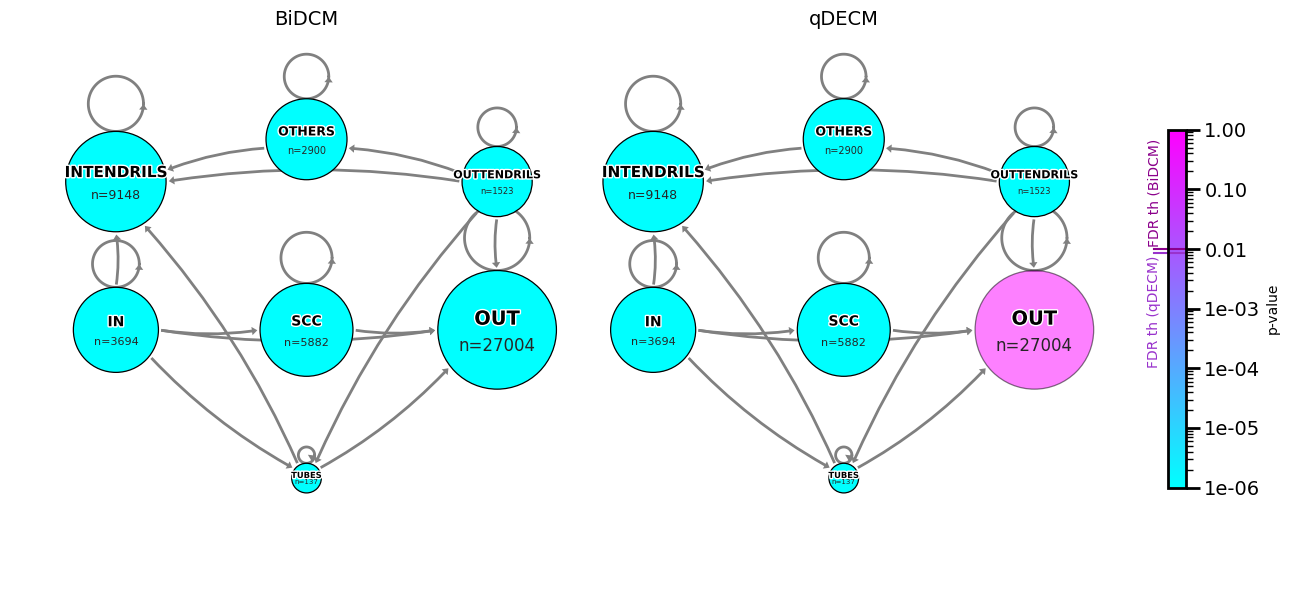

In [73]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
plot_bowtie_blocks(blocks[0], blocks[2], 0.01, ax=axs[0], vmin=vmin, show_colorbar=False)
plot_bowtie_blocks(blocks[1], blocks[2], 0.01, ax=axs[1], vmin=vmin, show_colorbar=False)
bnorm = mcolors.LogNorm(vmin=vmin, vmax=1.0)
bcmap = plt.get_cmap('cool')
cb=_add_colorbar(fig, axs, bcmap, bnorm, 'p-value',fdr_th=None, pad=0.02, orientation='vertical')
colors=['darkmagenta', 'darkorchid']
models=['BiDCM', 'qDECM']


x_text = -0.75
pairs = sorted(zip(fdr_blocks, models, colors), key=lambda t: t[0], reverse=True)
epsilon = 0.5 * (fdr_blocks[1] - fdr_blocks[0])
for (fdr_th, model, color), va in zip(pairs, ['bottom', 'top']):
    cb.ax.axhline(y=fdr_th, color=color, linestyle='-', linewidth=1.5)
    if va == 'bottom':
        y_text = fdr_th - epsilon
    else:        
        y_text = fdr_th + epsilon
    cb.ax.plot([x_text, 0], [fdr_th, fdr_th], color=color, linewidth=1.5,
clip_on=False, transform=cb.ax.get_yaxis_transform())
    cb.ax.text(x_text, y_text, f'FDR th ({model})', color=color,
        ha='center', va=va, fontsize=10, rotation=90,
        clip_on=False, transform=cb.ax.get_yaxis_transform())
for ax, model in zip(axs, models):
    ax.set_title(model, fontsize=14)
plt.show()

They seem identical, is it due to the two-tails test?

In [74]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [75]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
OUT: p-value=8.36e-01, tail=left
SCC: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
IN: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


No, but indeed the OUT block dimension is significant according to BiDCM, while it is not according to qDECM.

In [76]:
rt_blocks_0=right_tailer(blocks[0])
rt_blocks_1=right_tailer(blocks[1])

In [77]:
# handle minimum p-value for color scaling
vmin_blocks_0 =min([rt_blocks_0[key]['p_value'] for key in rt_blocks_0.keys()])
vmin_blocks_1 =min([rt_blocks_1[key]['p_value'] for key in rt_blocks_1.keys()])
vmin_blocks=min(vmin_blocks_0, vmin_blocks_1)

fdr_blocks_0 =fdr([rt_blocks_0[key]['p_value'] for key in rt_blocks_0.keys()], 0.01)
fdr_blocks_1 =fdr([rt_blocks_1[key]['p_value'] for key in rt_blocks_1.keys()], 0.01)
fdr_blocks=[fdr_blocks_0, fdr_blocks_1]
m_fdr_th=min(fdr_blocks)

vmin = 10 ** np.floor(np.log10(m_fdr_th))
vmin = min(vmin_blocks, vmin)
vmin = max(_PVAL_FLOOR, vmin)
vmin

1e-06

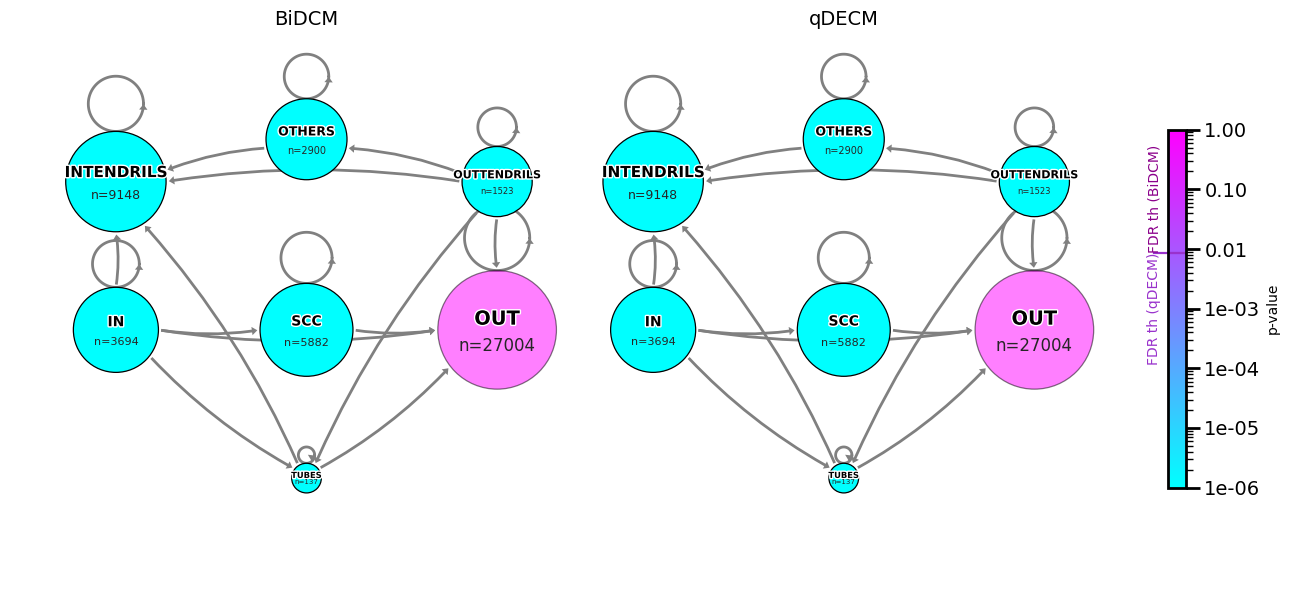

In [78]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
plot_bowtie_blocks(rt_blocks_0, blocks[2], 0.01, ax=axs[0], vmin=vmin, show_colorbar=False)
plot_bowtie_blocks(rt_blocks_1, blocks[2], 0.01, ax=axs[1], vmin=vmin, show_colorbar=False)
bnorm = mcolors.LogNorm(vmin=vmin, vmax=1.0)
bcmap = plt.get_cmap('cool')
cb=_add_colorbar(fig, axs, bcmap, bnorm, 'p-value',fdr_th=None, pad=0.02, orientation='vertical')
colors=['darkmagenta', 'darkorchid']
models=['BiDCM', 'qDECM']


x_text = -0.75
pairs = sorted(zip(fdr_blocks, models, colors), key=lambda t: t[0], reverse=True)
epsilon = 0.5 * (fdr_blocks[1] - fdr_blocks[0])
for (fdr_th, model, color), va in zip(pairs, ['bottom', 'top']):
    cb.ax.axhline(y=fdr_th, color=color, linestyle='-', linewidth=1.5)
    if va == 'bottom':
        y_text = fdr_th - epsilon
    else:        
        y_text = fdr_th + epsilon
    cb.ax.plot([x_text, 0], [fdr_th, fdr_th], color=color, linewidth=1.5,
clip_on=False, transform=cb.ax.get_yaxis_transform())
    cb.ax.text(x_text, y_text, f'FDR th ({model})', color=color,
        ha='center', va=va, fontsize=10, rotation=90,
        clip_on=False, transform=cb.ax.get_yaxis_transform())
for ax, model in zip(axs, models):
    ax.set_title(model, fontsize=14)
plt.show()

##### Fluxes

In [ ]:

# handle minimum p-value for color scaling
vmin_fluxes_0 =min([fluxes[0][key]['p_value'] for key in fluxes[0].keys()])
vmin_fluxes_1 =min([fluxes[1][key]['p_value'] for key in fluxes[1].keys()])
vmin_fluxes=min(vmin_fluxes_0, vmin_fluxes_1)

fdr_fluxes_0 =fdr([fluxes[0][key]['p_value'] for key in fluxes[0].keys()], alpha)
fdr_fluxes_1 =fdr([fluxes[1][key]['p_value'] for key in fluxes[1].keys()], alpha)
fdr_fluxes=[fdr_fluxes_0, fdr_fluxes_1]
m_fdr_th=min(fdr_fluxes)

vmin = 10 ** np.floor(np.log10(m_fdr_th))
vmin = min(vmin_fluxes, vmin)
vmin = max(_PVAL_FLOOR, vmin)
vmin

1e-06

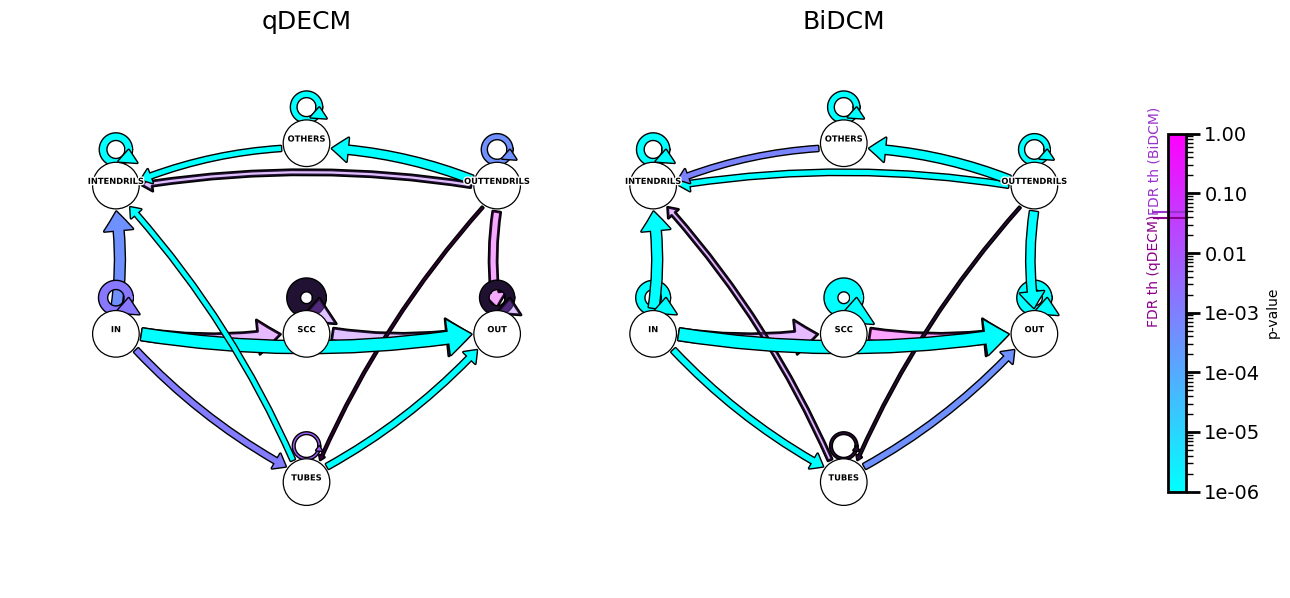

In [87]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
plot_bowtie_fluxes(fluxes[1], 0.01, ax=axs[0], show_colorbar=False, vmin=vmin)
plot_bowtie_fluxes(fluxes[0], 0.01, ax=axs[1], show_colorbar=False, vmin=vmin)


bnorm = mcolors.LogNorm(vmin=vmin, vmax=1.0)
bcmap = plt.get_cmap('cool')
cb=_add_colorbar(fig, axs, bcmap, bnorm, 'p-value',fdr_th=None, pad=0.02, orientation='vertical')
colors=['darkmagenta', 'darkorchid']
models=['qDECM', 'BiDCM']


x_text = -0.75
pairs = sorted(zip(fdr_fluxes, models, colors), key=lambda t: t[0], reverse=True)
epsilon = 0.5 * (fdr_fluxes[1] - fdr_fluxes[0])
for (fdr_th, model, color), va in zip(pairs, ['bottom', 'top']):
    cb.ax.axhline(y=fdr_th, color=color, linestyle='-', linewidth=1.5)
    if va == 'bottom':
        y_text = fdr_th - epsilon
    else:        
        y_text = fdr_th + epsilon
    cb.ax.plot([x_text, 0], [fdr_th, fdr_th], color=color, linewidth=1.5,
clip_on=False, transform=cb.ax.get_yaxis_transform())
    cb.ax.text(x_text, y_text, f'FDR th ({model})', color=color,
        ha='center', va=va, fontsize=10, rotation=90,
        clip_on=False, transform=cb.ax.get_yaxis_transform())
for ax, model in zip(axs, models):
    ax.set_title(model, fontsize=18)
plt.show()


In [88]:
rt_fluxes_0 = right_tailer(fluxes[0])
rt_fluxes_1 = right_tailer(fluxes[1])

In [89]:
# handle minimum p-value for color scaling
vmin_fluxes_0 =min([rt_fluxes_0[key]['p_value'] for key in rt_fluxes_0.keys()])
vmin_fluxes_1 =min([rt_fluxes_1[key]['p_value'] for key in rt_fluxes_1.keys()])
vmin_fluxes=min(vmin_fluxes_0, vmin_fluxes_1)

fdr_fluxes_0 =fdr([rt_fluxes_0[key]['p_value'] for key in rt_fluxes_0.keys()], alpha)
fdr_fluxes_1 =fdr([rt_fluxes_1[key]['p_value'] for key in rt_fluxes_1.keys()], alpha)
fdr_fluxes=[fdr_fluxes_0, fdr_fluxes_1]
m_fdr_th=min(fdr_fluxes)

vmin = 10 ** np.floor(np.log10(m_fdr_th))
vmin = min(vmin_fluxes, vmin)
vmin = max(_PVAL_FLOOR, vmin)
vmin

1e-06

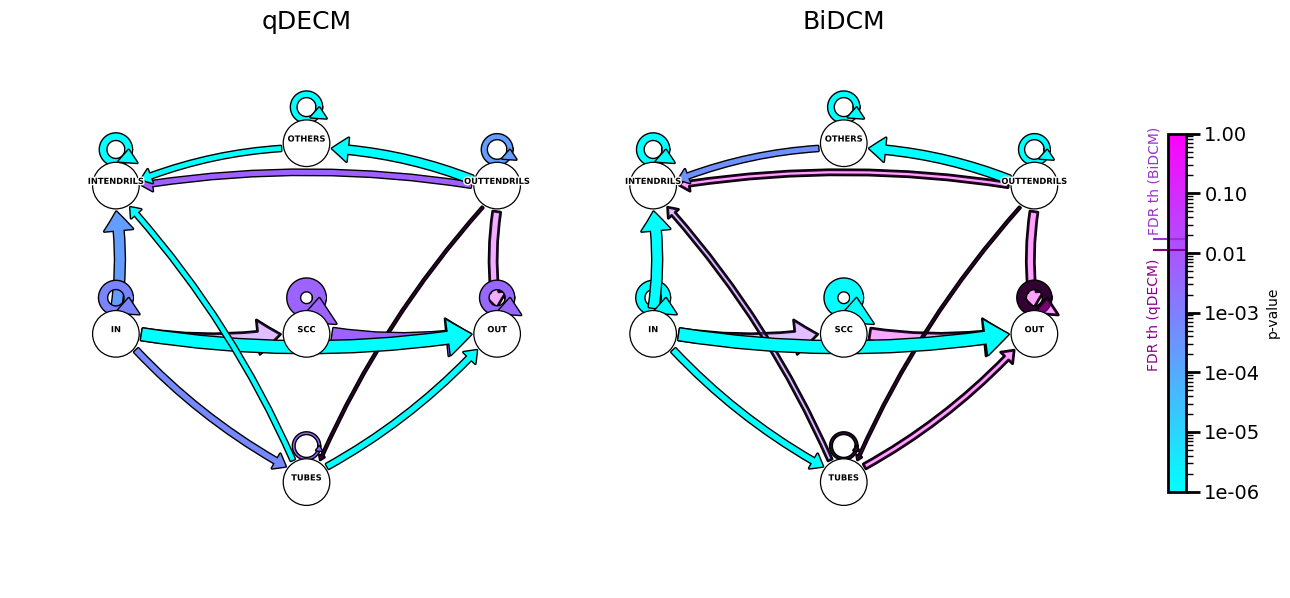

In [91]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
plot_bowtie_fluxes(rt_fluxes_1, 0.01, ax=axs[0], show_colorbar=False, vmin=vmin)
plot_bowtie_fluxes(rt_fluxes_0, 0.01, ax=axs[1], show_colorbar=False, vmin=vmin)


bnorm = mcolors.LogNorm(vmin=vmin, vmax=1.0)
bcmap = plt.get_cmap('cool')
cb=_add_colorbar(fig, axs, bcmap, bnorm, 'p-value',fdr_th=None, pad=0.02, orientation='vertical')
colors=['darkmagenta', 'darkorchid']
models=['qDECM', 'BiDCM']


x_text = -0.75
pairs = sorted(zip(fdr_fluxes, models, colors), key=lambda t: t[0], reverse=True)
epsilon = 0.5 * (fdr_fluxes[1] - fdr_fluxes[0])
for (fdr_th, model, color), va in zip(pairs, ['bottom', 'top']):
    cb.ax.axhline(y=fdr_th, color=color, linestyle='-', linewidth=1.5)
    if va == 'bottom':
        y_text = fdr_th + epsilon
    else:        
        y_text = fdr_th - epsilon
    cb.ax.plot([x_text, 0], [fdr_th, fdr_th], color=color, linewidth=1.5,
clip_on=False, transform=cb.ax.get_yaxis_transform())
    cb.ax.text(x_text, y_text, f'FDR th ({model})', color=color,
        ha='center', va=va, fontsize=10, rotation=90,
        clip_on=False, transform=cb.ax.get_yaxis_transform())
for ax, model in zip(axs, models):
    ax.set_title(model, fontsize=18)
plt.savefig(PLOT_FOLDER+f'{dataset}_{dico}_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


#### Distributions

In [47]:
from scipy.stats import norm

##### Blocks

In [48]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

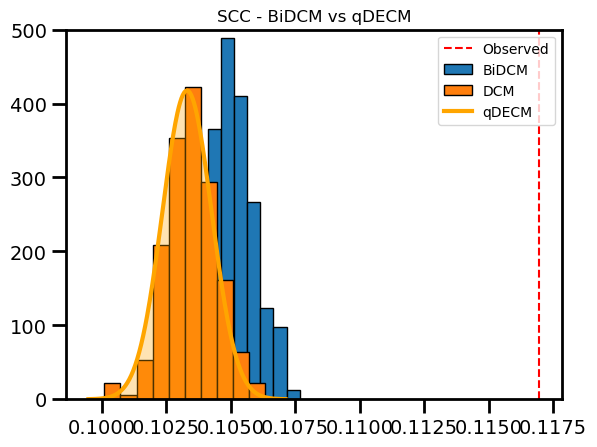

In [49]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
plt.hist(blocks_dcm[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='DCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [50]:
_block='OUTTENDRILS'

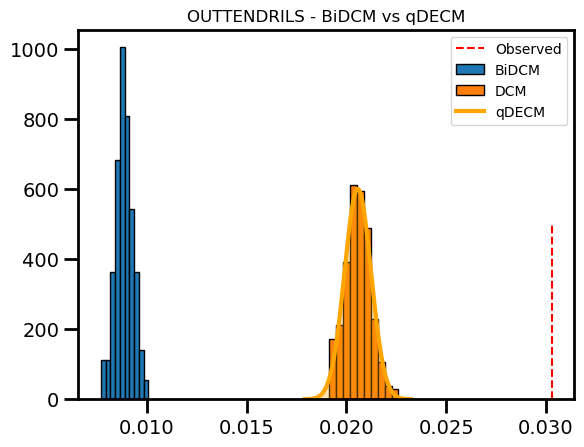

In [51]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
plt.hist(blocks_dcm[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='DCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

##### Fluxes

In [52]:
_flux='SCC->OUT'

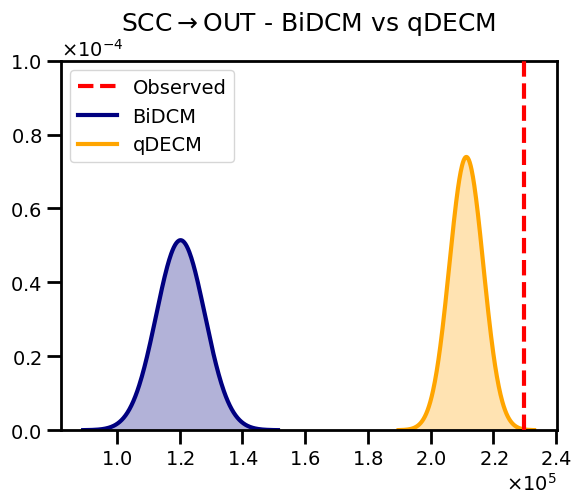

In [53]:
flux_latex=_flux.split('->')
flux_latex=r'$\rightarrow$'.join(flux_latex)

plt.vlines(fluxes[0][_flux]['obs'], ymin=0, ymax=1, color='red', linestyle='--', label='Observed', zorder=3, linewidth=3)
weights_0=np.ones(len(fluxes[0][_flux]['sample'])) / len(fluxes[0][_flux]['sample'])
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', weights=weights_0)
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', density=True)
mu_0=fluxes[0][_flux]['sample'].mean()
sig_0=fluxes[0][_flux]['sample'].std()
x = np.linspace(mu_0 - 4*sig_0, mu_0 + 4*sig_0, 300)
plt.plot(x, norm.pdf(x, mu_0, sig_0), color='navy', label='BiDCM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_0, sig_0), alpha=0.3, color='navy')
weights_1=np.ones(len(fluxes[1][_flux]['count_sample'])) / len(fluxes[1][_flux]['count_sample'])
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', weights=weights_1)
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', density=1)
mu_1=np.mean(fluxes[1][_flux]['count_sample'])
sig_1=np.std(fluxes[1][_flux]['count_sample'])
x = np.linspace(mu_1 - 4*sig_1, mu_1 + 4*sig_1, 300)
plt.plot(x, norm.pdf(x, mu_1, sig_1), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_1, sig_1), alpha=0.3, color='orange')

plt.ylim(0, 10**-4)
#plt.xscale('log')



ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.get_major_formatter().set_scientific(True)
ax.xaxis.get_major_formatter().set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

plt.title(f'{flux_latex} - BiDCM vs qDECM', fontsize=18)
plt.legend(fontsize=14)
_flux='_'.join(_flux.split('->'))
plt.savefig(PLOT_FOLDER+f'{dataset}_{dico}_{_flux}_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [54]:
_flux='IN->INTENDRILS'

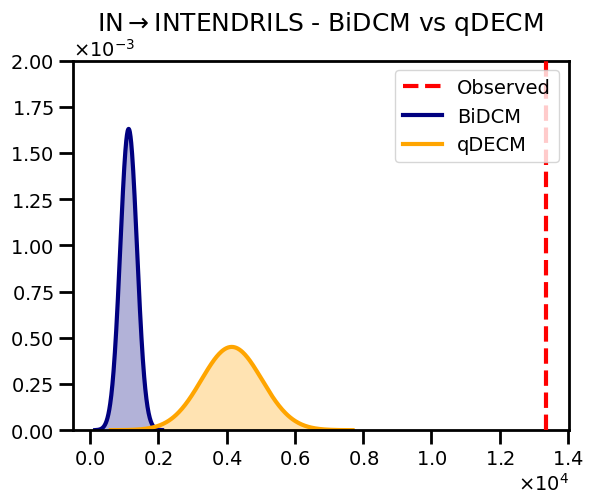

In [55]:
flux_latex=_flux.split('->')
flux_latex=r'$\rightarrow$'.join(flux_latex)

plt.vlines(fluxes[0][_flux]['obs'], ymin=0, ymax=1, color='red', linestyle='--', label='Observed', zorder=3, linewidth=3)
weights_0=np.ones(len(fluxes[0][_flux]['sample'])) / len(fluxes[0][_flux]['sample'])
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', weights=weights_0)
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', density=True)
mu_0=fluxes[0][_flux]['sample'].mean()
sig_0=fluxes[0][_flux]['sample'].std()
x = np.linspace(mu_0 - 4*sig_0, mu_0 + 4*sig_0, 300)
plt.plot(x, norm.pdf(x, mu_0, sig_0), color='navy', label='BiDCM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_0, sig_0), alpha=0.3, color='navy')
weights_1=np.ones(len(fluxes[1][_flux]['count_sample'])) / len(fluxes[1][_flux]['count_sample'])
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', weights=weights_1)
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', density=1)
mu_1=np.mean(fluxes[1][_flux]['count_sample'])
sig_1=np.std(fluxes[1][_flux]['count_sample'])
x = np.linspace(mu_1 - 4*sig_1, mu_1 + 4*sig_1, 300)
plt.plot(x, norm.pdf(x, mu_1, sig_1), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_1, sig_1), alpha=0.3, color='orange')

plt.ylim(0, 2*10**-3)
#plt.xscale('log')



ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.get_major_formatter().set_scientific(True)
ax.xaxis.get_major_formatter().set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

plt.title(f'{flux_latex} - BiDCM vs qDECM', fontsize=18)
plt.legend(fontsize=14)
_flux='_'.join(_flux.split('->'))
plt.savefig(PLOT_FOLDER+f'{dataset}_{dico}_{_flux}_comparison.png', dpi=300, bbox_inches='tight')

plt.show()


In [56]:
_flux='TUBES->OUT'

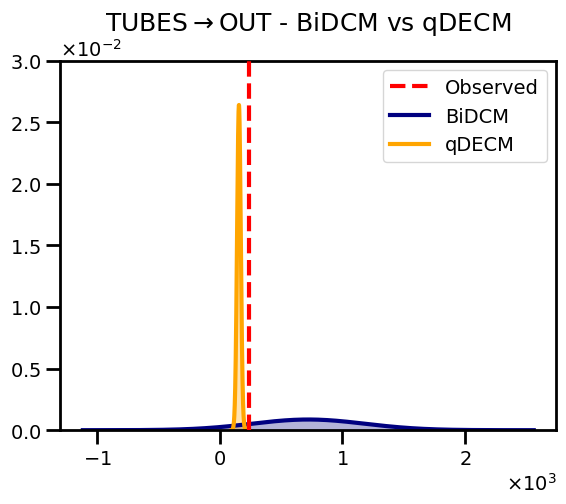

In [57]:
flux_latex=_flux.split('->')
flux_latex=r'$\rightarrow$'.join(flux_latex)

plt.vlines(fluxes[0][_flux]['obs'], ymin=0, ymax=1, color='red', linestyle='--', label='Observed', zorder=3, linewidth=3)
weights_0=np.ones(len(fluxes[0][_flux]['sample'])) / len(fluxes[0][_flux]['sample'])
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', weights=weights_0)
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', density=True)
mu_0=fluxes[0][_flux]['sample'].mean()
sig_0=fluxes[0][_flux]['sample'].std()
x = np.linspace(mu_0 - 4*sig_0, mu_0 + 4*sig_0, 300)
plt.plot(x, norm.pdf(x, mu_0, sig_0), color='navy', label='BiDCM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_0, sig_0), alpha=0.3, color='navy')
weights_1=np.ones(len(fluxes[1][_flux]['count_sample'])) / len(fluxes[1][_flux]['count_sample'])
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', weights=weights_1)
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', density=1)
mu_1=np.mean(fluxes[1][_flux]['count_sample'])
sig_1=np.std(fluxes[1][_flux]['count_sample'])
x = np.linspace(mu_1 - 4*sig_1, mu_1 + 4*sig_1, 300)
plt.plot(x, norm.pdf(x, mu_1, sig_1), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_1, sig_1), alpha=0.3, color='orange')

plt.ylim(0, 3*10**-2)
#plt.xscale('log')



ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.get_major_formatter().set_scientific(True)
ax.xaxis.get_major_formatter().set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

plt.title(f'{flux_latex} - BiDCM vs qDECM', fontsize=18)
plt.legend(fontsize=14)
plt.show()


### Italia Viva & Azione

In [92]:
dataset='ita_elections'
dico=3

#### Bowtie

In [93]:
blocks=guarino2dict_blocks(dataset, dico)
blocks_dcm=guarino2dict_blocks_DCM(dataset, dico)
fluxes=guarino2dict_fluxes(dataset, dico)

In [94]:
users=0
for key in blocks[0].keys():
    users+=blocks[0][key]['obs']

In [95]:
rts=0
for key in blocks[2].keys():
    rts+=blocks[2][key]['obs']

In [96]:
users, rts

(28156, np.int32(585916))

##### Blocks

In [89]:
# handle minimum p-value for color scaling
vmin_blocks_0 =min([blocks[0][key]['p_value'] for key in blocks[0].keys()])
vmin_blocks_1 =min([blocks[1][key]['p_value'] for key in blocks[1].keys()])
vmin_blocks=min(vmin_blocks_0, vmin_blocks_1)

fdr_blocks_0 =fdr([blocks[0][key]['p_value'] for key in blocks[0].keys()], 0.01)
fdr_blocks_1 =fdr([blocks[1][key]['p_value'] for key in blocks[1].keys()], 0.01)
fdr_blocks=[fdr_blocks_0, fdr_blocks_1]
m_fdr_th=min(fdr_blocks)

vmin = 10 ** np.floor(np.log10(m_fdr_th))
vmin = min(vmin_blocks, vmin)
vmin = max(_PVAL_FLOOR, vmin)
vmin

1e-06

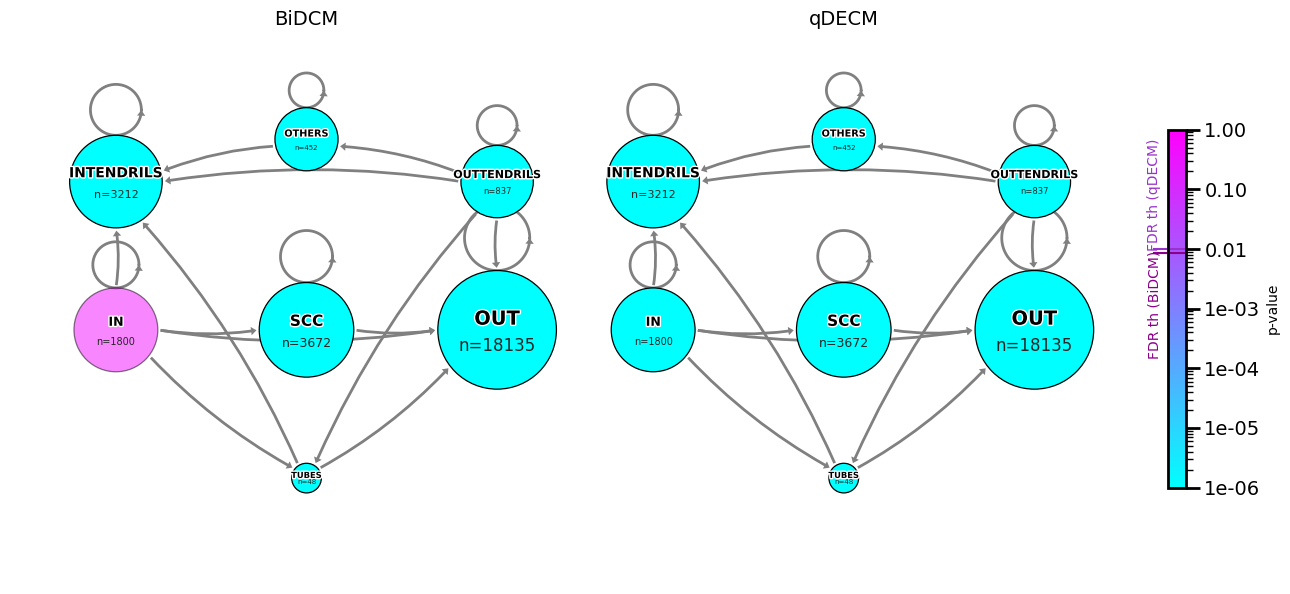

In [90]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
plot_bowtie_blocks(blocks[0], blocks[2], 0.01, ax=axs[0], vmin=vmin, show_colorbar=False)
plot_bowtie_blocks(blocks[1], blocks[2], 0.01, ax=axs[1], vmin=vmin, show_colorbar=False)
bnorm = mcolors.LogNorm(vmin=vmin, vmax=1.0)
bcmap = plt.get_cmap('cool')
cb=_add_colorbar(fig, axs, bcmap, bnorm, 'p-value',fdr_th=None, pad=0.02, orientation='vertical')
colors=['darkmagenta', 'darkorchid']
models=['BiDCM', 'qDECM']


x_text = -0.75
pairs = sorted(zip(fdr_blocks, models, colors), key=lambda t: t[0], reverse=True)
epsilon = 0.5 * (fdr_blocks[1] - fdr_blocks[0])
for (fdr_th, model, color), va in zip(pairs, ['bottom', 'top']):
    cb.ax.axhline(y=fdr_th, color=color, linestyle='-', linewidth=1.5)
    if va == 'bottom':
        y_text = fdr_th - epsilon
    else:        
        y_text = fdr_th + epsilon
    cb.ax.plot([x_text, 0], [fdr_th, fdr_th], color=color, linewidth=1.5,
clip_on=False, transform=cb.ax.get_yaxis_transform())
    cb.ax.text(x_text, y_text, f'FDR th ({model})', color=color,
        ha='center', va=va, fontsize=10, rotation=90,
        clip_on=False, transform=cb.ax.get_yaxis_transform())
for ax, model in zip(axs, models):
    ax.set_title(model, fontsize=14)
plt.show()

They seem identical, is it due to the two-tails test?

In [91]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=4.67e-01, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [92]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUT: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
IN: p-value=0.00e+00, tail=left
OTHERS: p-value=0.00e+00, tail=right


No, but indeed the IN block dimension is significant according to qDECM, while it is not according to BiDCM.

In [93]:
rt_blocks_0=right_tailer(blocks[0])
rt_blocks_1=right_tailer(blocks[1])

In [94]:
# handle minimum p-value for color scaling
vmin_blocks_0 =min([rt_blocks_0[key]['p_value'] for key in rt_blocks_0.keys()])
vmin_blocks_1 =min([rt_blocks_1[key]['p_value'] for key in rt_blocks_1.keys()])
vmin_blocks=min(vmin_blocks_0, vmin_blocks_1)

fdr_blocks_0 =fdr([rt_blocks_0[key]['p_value'] for key in rt_blocks_0.keys()], 0.01)
fdr_blocks_1 =fdr([rt_blocks_1[key]['p_value'] for key in rt_blocks_1.keys()], 0.01)
fdr_blocks=[fdr_blocks_0, fdr_blocks_1]
m_fdr_th=min(fdr_blocks)

vmin = 10 ** np.floor(np.log10(m_fdr_th))
vmin = min(vmin_blocks, vmin)
vmin = max(_PVAL_FLOOR, vmin)
vmin

1e-06

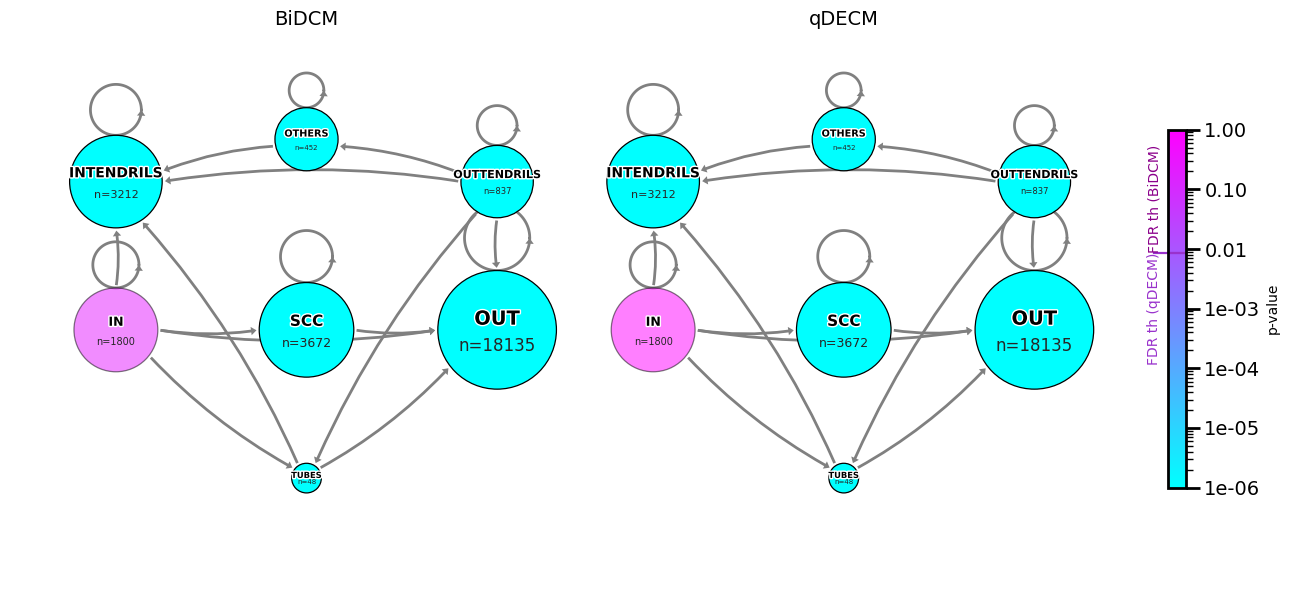

In [95]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
plot_bowtie_blocks(rt_blocks_0, blocks[2], 0.01, ax=axs[0], vmin=vmin, show_colorbar=False)
plot_bowtie_blocks(rt_blocks_1, blocks[2], 0.01, ax=axs[1], vmin=vmin, show_colorbar=False)
bnorm = mcolors.LogNorm(vmin=vmin, vmax=1.0)
bcmap = plt.get_cmap('cool')
cb=_add_colorbar(fig, axs, bcmap, bnorm, 'p-value',fdr_th=None, pad=0.02, orientation='vertical')
colors=['darkmagenta', 'darkorchid']
models=['BiDCM', 'qDECM']


x_text = -0.75
pairs = sorted(zip(fdr_blocks, models, colors), key=lambda t: t[0], reverse=True)
epsilon = 0.5 * (fdr_blocks[1] - fdr_blocks[0])
for (fdr_th, model, color), va in zip(pairs, ['bottom', 'top']):
    cb.ax.axhline(y=fdr_th, color=color, linestyle='-', linewidth=1.5)
    if va == 'bottom':
        y_text = fdr_th - epsilon
    else:        
        y_text = fdr_th + epsilon
    cb.ax.plot([x_text, 0], [fdr_th, fdr_th], color=color, linewidth=1.5,
clip_on=False, transform=cb.ax.get_yaxis_transform())
    cb.ax.text(x_text, y_text, f'FDR th ({model})', color=color,
        ha='center', va=va, fontsize=10, rotation=90,
        clip_on=False, transform=cb.ax.get_yaxis_transform())
for ax, model in zip(axs, models):
    ax.set_title(model, fontsize=14)
plt.show()

##### Fluxes

In [97]:
# handle minimum p-value for color scaling
vmin_fluxes_0 =min([fluxes[0][key]['p_value'] for key in fluxes[0].keys()])
vmin_fluxes_1 =min([fluxes[1][key]['p_value'] for key in fluxes[1].keys()])
vmin_fluxes_2 =min([fluxes[2][key]['p_value'] for key in fluxes[2].keys()])
vmin_fluxes=min(vmin_fluxes_0, vmin_fluxes_1, vmin_fluxes_2)

fdr_fluxes_0 =fdr([fluxes[0][key]['p_value'] for key in fluxes[0].keys()], alpha)
fdr_fluxes_1 =fdr([fluxes[1][key]['p_value'] for key in fluxes[1].keys()], alpha)
fdr_fluxes_2 =fdr([fluxes[2][key]['p_value'] for key in fluxes[2].keys()], alpha)
fdr_fluxes=[fdr_fluxes_0, fdr_fluxes_1, fdr_fluxes_2]
m_fdr_th=min(fdr_fluxes)

vmin = 10 ** np.floor(np.log10(m_fdr_th))
vmin = min(vmin_fluxes, vmin)
vmin = max(_PVAL_FLOOR, vmin)
vmin

1e-06

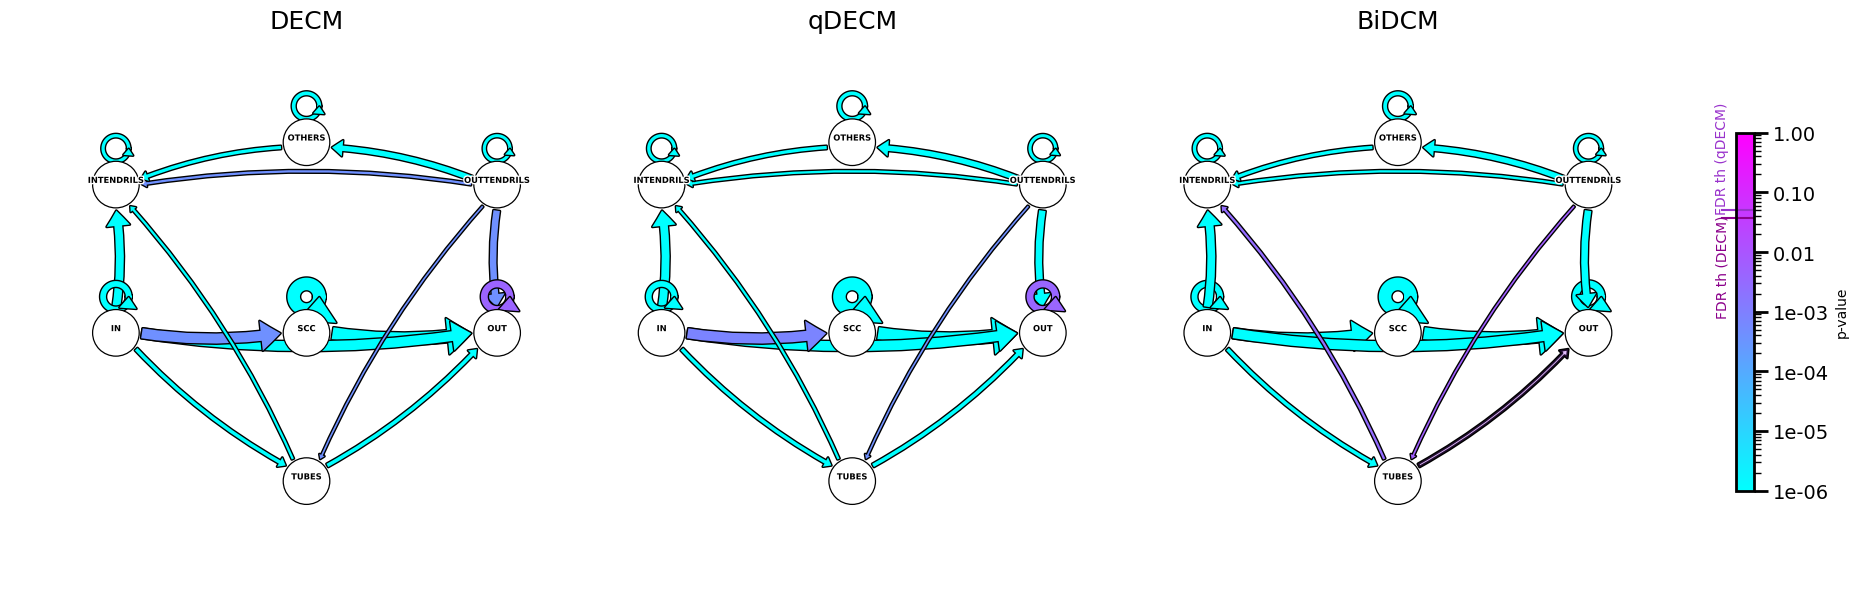

In [98]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(21, 6))
plot_bowtie_fluxes(fluxes[2], 0.01, ax=axs[0], show_colorbar=False, vmin=vmin)
plot_bowtie_fluxes(fluxes[1], 0.01, ax=axs[1], show_colorbar=False, vmin=vmin)
plot_bowtie_fluxes(fluxes[0], 0.01, ax=axs[2], show_colorbar=False, vmin=vmin)


bnorm = mcolors.LogNorm(vmin=vmin, vmax=1.0)
bcmap = plt.get_cmap('cool')
cb=_add_colorbar(fig, axs, bcmap, bnorm, 'p-value',fdr_th=None, pad=0.02, orientation='vertical')
colors=['darkmagenta', 'darkorchid']
models=['DECM', 'qDECM', 'BiDCM']


x_text = -0.75
pairs = sorted(zip(fdr_fluxes, models, colors), key=lambda t: t[0], reverse=True)
epsilon = 0.5 * (fdr_fluxes[1] - fdr_fluxes[0])
for (fdr_th, model, color), va in zip(pairs, ['bottom', 'top']):
    cb.ax.axhline(y=fdr_th, color=color, linestyle='-', linewidth=1.5)
    if va == 'bottom':
        y_text = fdr_th - epsilon
    else:        
        y_text = fdr_th + epsilon
    cb.ax.plot([x_text, 0], [fdr_th, fdr_th], color=color, linewidth=1.5,
clip_on=False, transform=cb.ax.get_yaxis_transform())
    cb.ax.text(x_text, y_text, f'FDR th ({model})', color=color,
        ha='center', va=va, fontsize=10, rotation=90,
        clip_on=False, transform=cb.ax.get_yaxis_transform())
for ax, model in zip(axs, models):
    ax.set_title(model, fontsize=18)
plt.show()


In [113]:
pvals_decm=[fluxes[2][key]['p_value'] for key in fluxes[2].keys()]
pvals_qdecm=[fluxes[1][key]['p_value'] for key in fluxes[1].keys()]
np.vstack((pvals_decm, pvals_qdecm)).T

array([[0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [2.0e-04, 4.0e-04],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [2.0e-04, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [2.2e-03, 2.0e-03],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [2.0e-04, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [2.0e-04, 2.0e-04],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
 

In [114]:
pvals_decm=[10**-10 if p==0 else p for p in pvals_decm]
pvals_qdecm=[10**-10 if p==0 else p for p in pvals_qdecm]

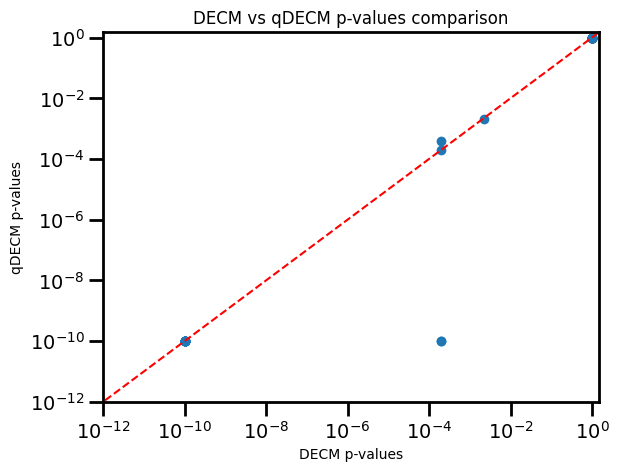

In [117]:
plt.scatter(pvals_decm, pvals_qdecm)
plt.xscale('log')
plt.yscale('log')
plt.plot([1e-15, 2], [1e-15, 2], color='red', linestyle='--')
plt.xlabel('DECM p-values')
plt.ylabel('qDECM p-values')
plt.title('DECM vs qDECM p-values comparison')
plt.xlim(1e-12, 1.5)
plt.ylim(1e-12, 1.5)
plt.show()

In [118]:
rt_fluxes_0 = right_tailer(fluxes[0])
rt_fluxes_1 = right_tailer(fluxes[1])
rt_fluxes_2 = right_tailer(fluxes[2])

In [119]:
# handle minimum p-value for color scaling
vmin_fluxes_0 =min([rt_fluxes_0[key]['p_value'] for key in rt_fluxes_0.keys()])
vmin_fluxes_1 =min([rt_fluxes_1[key]['p_value'] for key in rt_fluxes_1.keys()])
vmin_fluxes_2 =min([rt_fluxes_2[key]['p_value'] for key in rt_fluxes_2.keys()])
vmin_fluxes=min(vmin_fluxes_0, vmin_fluxes_1, vmin_fluxes_2)

fdr_fluxes_0 =fdr([rt_fluxes_0[key]['p_value'] for key in rt_fluxes_0.keys()], alpha)
fdr_fluxes_1 =fdr([rt_fluxes_1[key]['p_value'] for key in rt_fluxes_1.keys()], alpha)
fdr_fluxes_2 =fdr([rt_fluxes_2[key]['p_value'] for key in rt_fluxes_2.keys()], alpha)
fdr_fluxes=[fdr_fluxes_0, fdr_fluxes_1, fdr_fluxes_2]
m_fdr_th=min(fdr_fluxes)

vmin = 10 ** np.floor(np.log10(m_fdr_th))
vmin = min(vmin_fluxes, vmin)
vmin = max(_PVAL_FLOOR, vmin)
vmin

1e-06

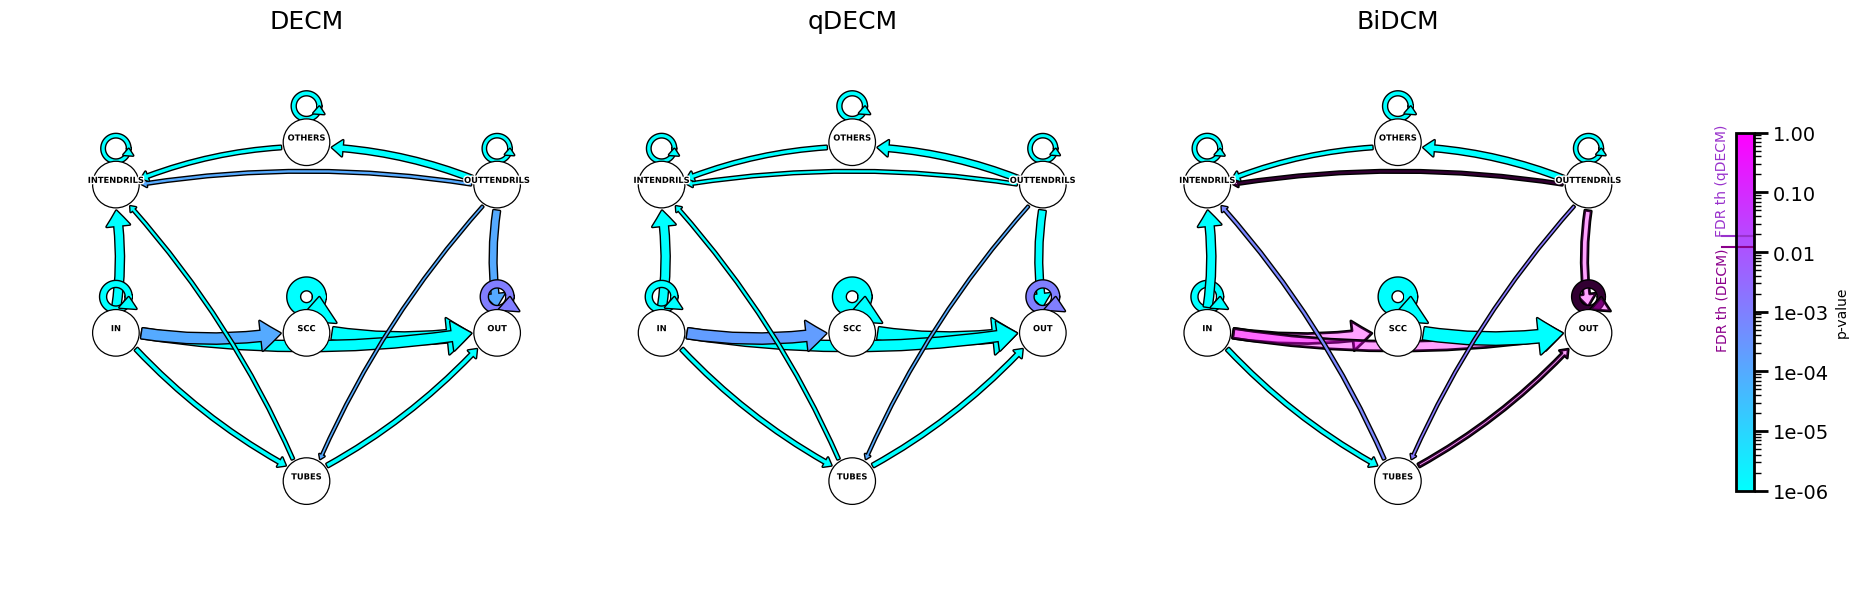

In [120]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(21, 6))
plot_bowtie_fluxes(rt_fluxes_2, 0.01, ax=axs[0], show_colorbar=False, vmin=vmin)
plot_bowtie_fluxes(rt_fluxes_1, 0.01, ax=axs[1], show_colorbar=False, vmin=vmin)
plot_bowtie_fluxes(rt_fluxes_0, 0.01, ax=axs[2], show_colorbar=False, vmin=vmin)


bnorm = mcolors.LogNorm(vmin=vmin, vmax=1.0)
bcmap = plt.get_cmap('cool')
cb=_add_colorbar(fig, axs, bcmap, bnorm, 'p-value',fdr_th=None, pad=0.02, orientation='vertical')
colors=['darkmagenta', 'darkorchid']
models=['DECM', 'qDECM', 'BiDCM']


x_text = -0.75
pairs = sorted(zip(fdr_fluxes, models, colors), key=lambda t: t[0], reverse=True)
epsilon = 5*10**-2 * (fdr_fluxes[1] - fdr_fluxes[0])
for (fdr_th, model, color), va in zip(pairs, ['bottom', 'top']):
    cb.ax.axhline(y=fdr_th, color=color, linestyle='-', linewidth=1.5)
    if va == 'bottom':
        y_text = fdr_th + epsilon
    else:        
        y_text = fdr_th - epsilon
    cb.ax.plot([x_text, 0], [fdr_th, fdr_th], color=color, linewidth=1.5,
clip_on=False, transform=cb.ax.get_yaxis_transform())
    cb.ax.text(x_text, y_text, f'FDR th ({model})', color=color,
        ha='center', va=va, fontsize=10, rotation=90,
        clip_on=False, transform=cb.ax.get_yaxis_transform())
for ax, model in zip(axs, models):
    ax.set_title(model, fontsize=18)
plt.savefig(PLOT_FOLDER+f'{dataset}_{dico}_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [124]:
rt_pvals_decm=[rt_fluxes_2[key]['p_value'] for key in rt_fluxes_2.keys()]
rt_pvals_qdecm=[rt_fluxes_1[key]['p_value'] for key in rt_fluxes_1.keys()]
np.vstack((rt_pvals_decm, rt_pvals_qdecm)).T

array([[0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [1.0e-04, 2.0e-04],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [1.0e-04, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [1.1e-03, 1.0e-03],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [1.0e-04, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00],
       [1.0e-04, 1.0e-04],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
       [1.0e+00, 1.0e+00],
 

In [125]:
rt_pvals_decm=[10**-10 if p==0 else p for p in rt_pvals_decm]
rt_pvals_qdecm=[10**-10 if p==0 else p for p in rt_pvals_qdecm]

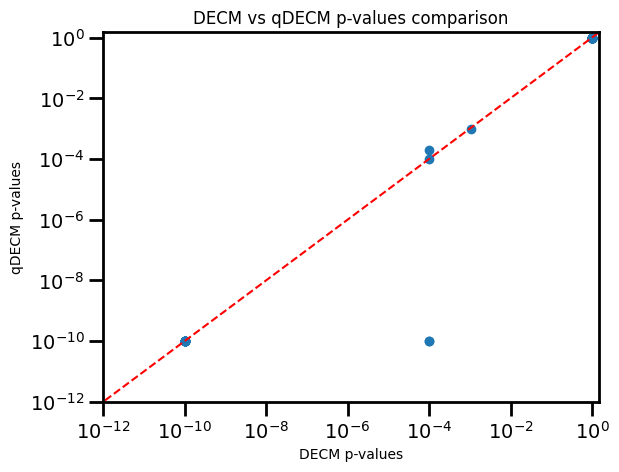

In [126]:
plt.scatter(rt_pvals_decm, rt_pvals_qdecm)
plt.xscale('log')
plt.yscale('log')
plt.plot([1e-15, 2], [1e-15, 2], color='red', linestyle='--')
plt.xlabel('DECM p-values')
plt.ylabel('qDECM p-values')
plt.title('DECM vs qDECM p-values comparison')
plt.xlim(1e-12, 1.5)
plt.ylim(1e-12, 1.5)
plt.show()

In [131]:
for key in rt_fluxes_2.keys():
    print(f"{key:<25}: DECM={rt_fluxes_2[key]['p_value']:.4e}, qDECM={rt_fluxes_1[key]['p_value']:.4e}")

SCC->SCC                 : DECM=0.0000e+00, qDECM=0.0000e+00
SCC->OUT                 : DECM=0.0000e+00, qDECM=0.0000e+00
IN->OUT                  : DECM=0.0000e+00, qDECM=0.0000e+00
IN->INTENDRILS           : DECM=0.0000e+00, qDECM=0.0000e+00
IN->SCC                  : DECM=1.0000e-04, qDECM=2.0000e-04
IN->TUBES                : DECM=0.0000e+00, qDECM=0.0000e+00
IN->IN                   : DECM=0.0000e+00, qDECM=0.0000e+00
OUTTENDRILS->OUT         : DECM=1.0000e-04, qDECM=0.0000e+00
OUTTENDRILS->OUTTENDRILS : DECM=0.0000e+00, qDECM=0.0000e+00
OUTTENDRILS->OTHERS      : DECM=0.0000e+00, qDECM=0.0000e+00
OUT->OUT                 : DECM=1.1000e-03, qDECM=1.0000e-03
INTENDRILS->INTENDRILS   : DECM=0.0000e+00, qDECM=0.0000e+00
TUBES->OUT               : DECM=0.0000e+00, qDECM=0.0000e+00
OTHERS->OTHERS           : DECM=0.0000e+00, qDECM=0.0000e+00
OUTTENDRILS->INTENDRILS  : DECM=1.0000e-04, qDECM=0.0000e+00
OTHERS->INTENDRILS       : DECM=0.0000e+00, qDECM=0.0000e+00
TUBES->INTENDRILS       

Probavbly the mismatch is due only to differences in sampling.

#### Distributions

In [224]:
from scipy.stats import norm

##### Blocks

In [ ]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

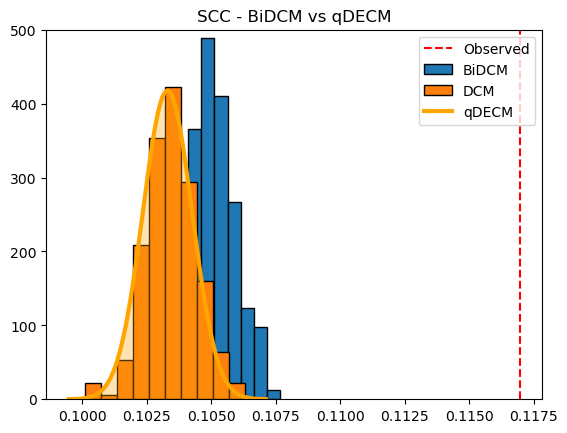

In [ ]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
plt.hist(blocks_dcm[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='DCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [ ]:
_block='OUTTENDRILS'

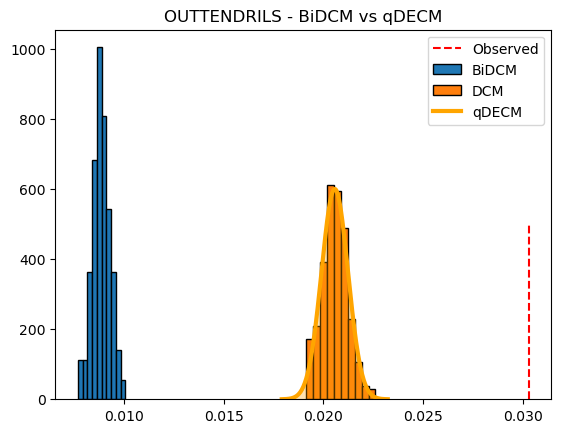

In [ ]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
plt.hist(blocks_dcm[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='DCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

##### Fluxes

In [240]:
_flux='IN->SCC'

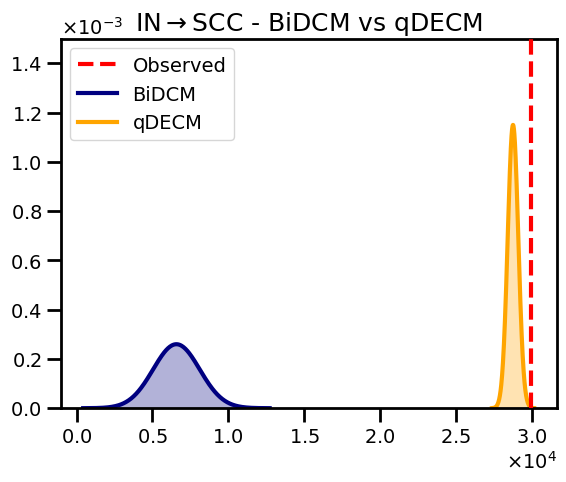

In [241]:
flux_latex=_flux.split('->')
flux_latex=r'$\rightarrow$'.join(flux_latex)

plt.vlines(fluxes[0][_flux]['obs'], ymin=0, ymax=1, color='red', linestyle='--', label='Observed', zorder=3, linewidth=3)
weights_0=np.ones(len(fluxes[0][_flux]['sample'])) / len(fluxes[0][_flux]['sample'])
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', weights=weights_0)
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', density=True)
mu_0=fluxes[0][_flux]['sample'].mean()
sig_0=fluxes[0][_flux]['sample'].std()
x = np.linspace(mu_0 - 4*sig_0, mu_0 + 4*sig_0, 300)
plt.plot(x, norm.pdf(x, mu_0, sig_0), color='navy', label='BiDCM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_0, sig_0), alpha=0.3, color='navy')
weights_1=np.ones(len(fluxes[1][_flux]['count_sample'])) / len(fluxes[1][_flux]['count_sample'])
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', weights=weights_1)
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', density=1)
mu_1=np.mean(fluxes[1][_flux]['count_sample'])
sig_1=np.std(fluxes[1][_flux]['count_sample'])
x = np.linspace(mu_1 - 4*sig_1, mu_1 + 4*sig_1, 300)
plt.plot(x, norm.pdf(x, mu_1, sig_1), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_1, sig_1), alpha=0.3, color='orange')

plt.ylim(0, 1.5*10**-3)
#plt.xscale('log')



ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.get_major_formatter().set_scientific(True)
ax.xaxis.get_major_formatter().set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

plt.title(f'{flux_latex} - BiDCM vs qDECM', fontsize=18)
plt.legend(fontsize=14)
_flux='_'.join(_flux.split('->'))
plt.savefig(PLOT_FOLDER+f'{dataset}_{dico}_{_flux}_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [243]:
_flux='IN->IN'

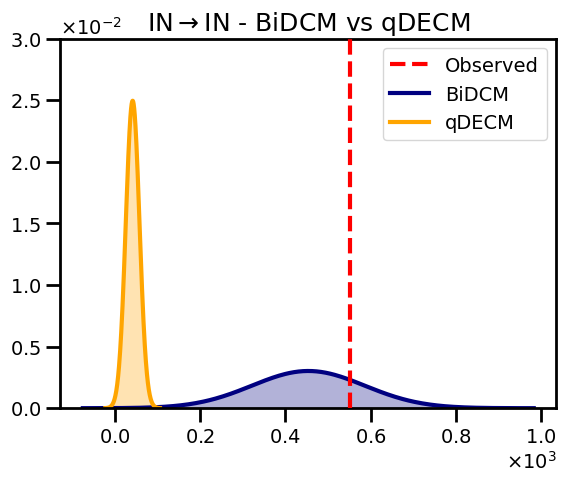

In [244]:
flux_latex=_flux.split('->')
flux_latex=r'$\rightarrow$'.join(flux_latex)

plt.vlines(fluxes[0][_flux]['obs'], ymin=0, ymax=1, color='red', linestyle='--', label='Observed', zorder=3, linewidth=3)
weights_0=np.ones(len(fluxes[0][_flux]['sample'])) / len(fluxes[0][_flux]['sample'])
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', weights=weights_0)
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', density=True)
mu_0=fluxes[0][_flux]['sample'].mean()
sig_0=fluxes[0][_flux]['sample'].std()
x = np.linspace(mu_0 - 4*sig_0, mu_0 + 4*sig_0, 300)
plt.plot(x, norm.pdf(x, mu_0, sig_0), color='navy', label='BiDCM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_0, sig_0), alpha=0.3, color='navy')
weights_1=np.ones(len(fluxes[1][_flux]['count_sample'])) / len(fluxes[1][_flux]['count_sample'])
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', weights=weights_1)
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', density=1)
mu_1=np.mean(fluxes[1][_flux]['count_sample'])
sig_1=np.std(fluxes[1][_flux]['count_sample'])
x = np.linspace(mu_1 - 4*sig_1, mu_1 + 4*sig_1, 300)
plt.plot(x, norm.pdf(x, mu_1, sig_1), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_1, sig_1), alpha=0.3, color='orange')

plt.ylim(0, 3*10**-2)
#plt.xscale('log')



ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.get_major_formatter().set_scientific(True)
ax.xaxis.get_major_formatter().set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

plt.title(f'{flux_latex} - BiDCM vs qDECM', fontsize=18)
plt.legend(fontsize=14)
_flux='_'.join(_flux.split('->'))
plt.savefig(PLOT_FOLDER+f'{dataset}_{dico}_{_flux}_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
_flux='TUBES->OUT'

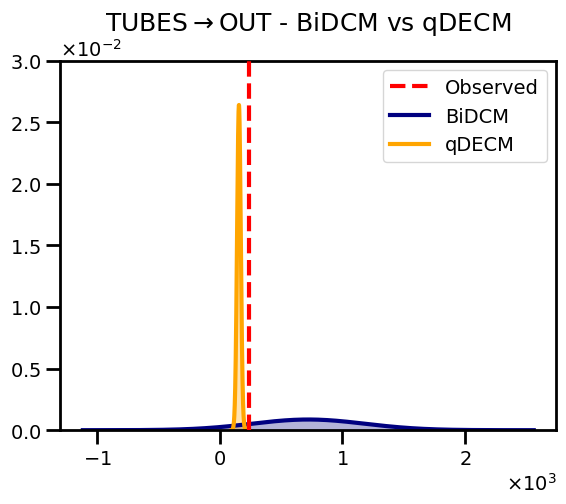

In [ ]:
flux_latex=_flux.split('->')
flux_latex=r'$\rightarrow$'.join(flux_latex)

plt.vlines(fluxes[0][_flux]['obs'], ymin=0, ymax=1, color='red', linestyle='--', label='Observed', zorder=3, linewidth=3)
weights_0=np.ones(len(fluxes[0][_flux]['sample'])) / len(fluxes[0][_flux]['sample'])
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', weights=weights_0)
#plt.hist(fluxes[0][_flux]['sample'], bins=7, edgecolor='black', label='BiDCM', density=True)
mu_0=fluxes[0][_flux]['sample'].mean()
sig_0=fluxes[0][_flux]['sample'].std()
x = np.linspace(mu_0 - 4*sig_0, mu_0 + 4*sig_0, 300)
plt.plot(x, norm.pdf(x, mu_0, sig_0), color='navy', label='BiDCM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_0, sig_0), alpha=0.3, color='navy')
weights_1=np.ones(len(fluxes[1][_flux]['count_sample'])) / len(fluxes[1][_flux]['count_sample'])
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', weights=weights_1)
#plt.hist(np.array(fluxes[1][_flux]['count_sample']), bins=25, edgecolor='black', label='qDECM', density=1)
mu_1=np.mean(fluxes[1][_flux]['count_sample'])
sig_1=np.std(fluxes[1][_flux]['count_sample'])
x = np.linspace(mu_1 - 4*sig_1, mu_1 + 4*sig_1, 300)
plt.plot(x, norm.pdf(x, mu_1, sig_1), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu_1, sig_1), alpha=0.3, color='orange')

plt.ylim(0, 3*10**-2)
#plt.xscale('log')



ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.get_major_formatter().set_scientific(True)
ax.xaxis.get_major_formatter().set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

plt.title(f'{flux_latex} - BiDCM vs qDECM', fontsize=18)
plt.legend(fontsize=14)
plt.show()


### PD

#### Bowties

In [101]:
blocks=guarino2dict_blocks('ita_elections', 1)

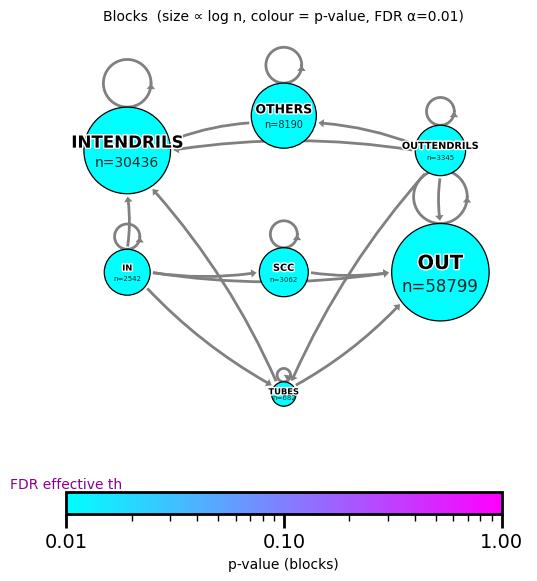

In [102]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

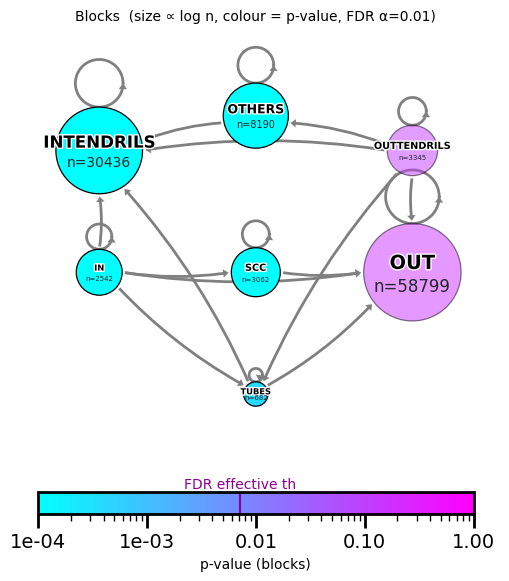

In [103]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [104]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=left
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [105]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUT: p-value=1.56e-01, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
TUBES: p-value=4.00e-04, tail=right
OUTTENDRILS: p-value=1.08e-01, tail=left
IN: p-value=0.00e+00, tail=right


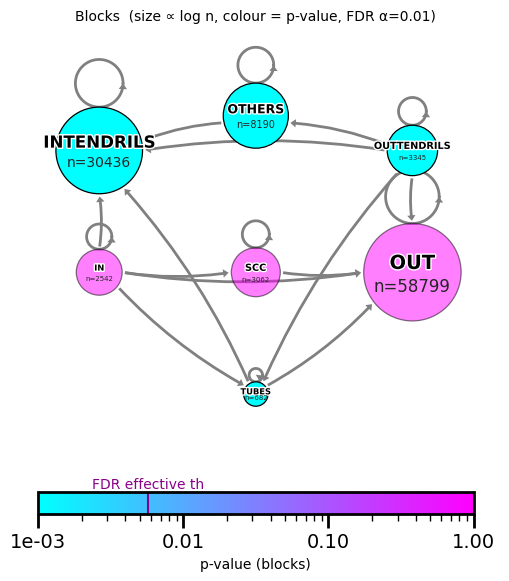

In [106]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

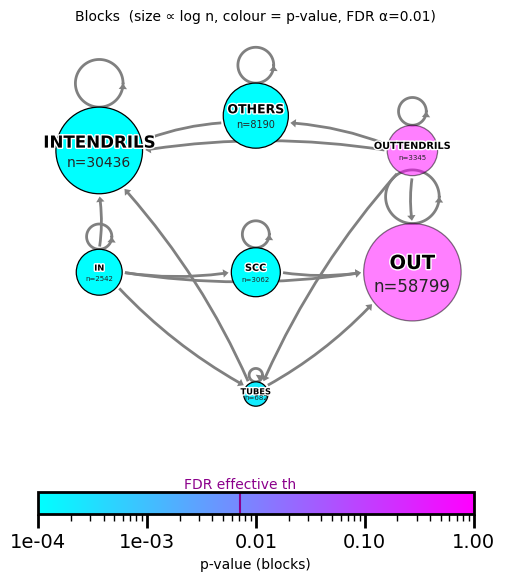

In [107]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

#### Distributions

In [ ]:
from scipy.stats import norm

In [ ]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

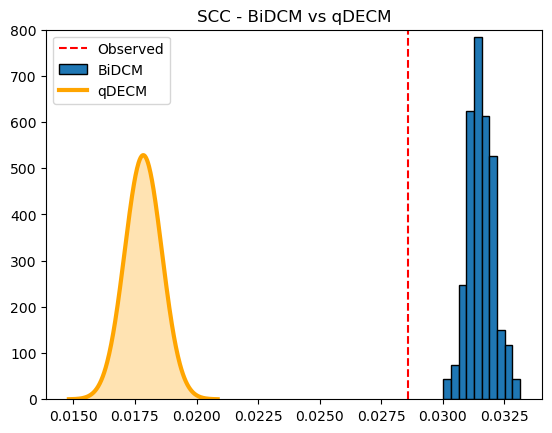

In [ ]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 8*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [ ]:
_block='OUTTENDRILS'

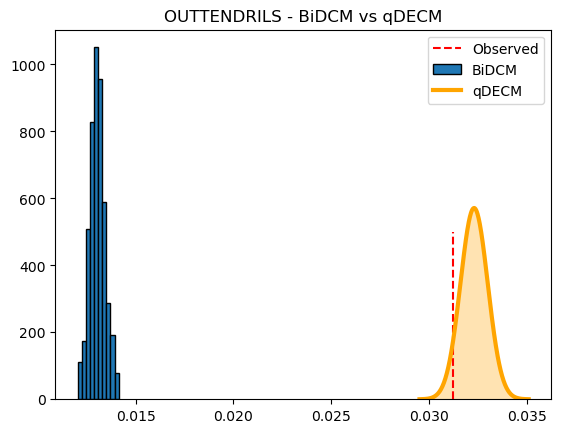

In [ ]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### M5S

#### Bowties

In [ ]:
blocks=guarino2dict_blocks('ita_elections', 2)

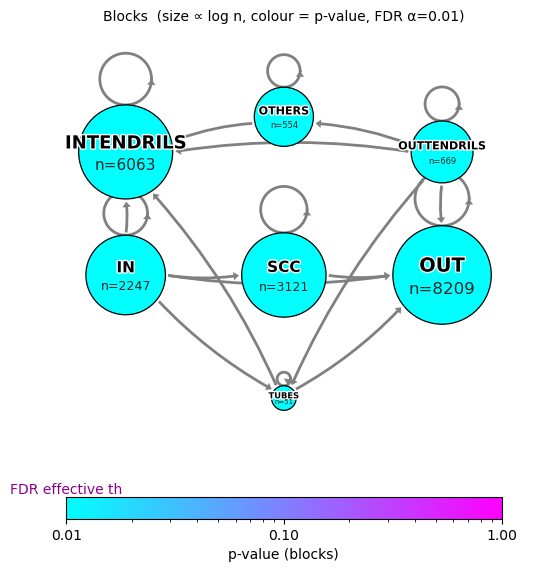

In [ ]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

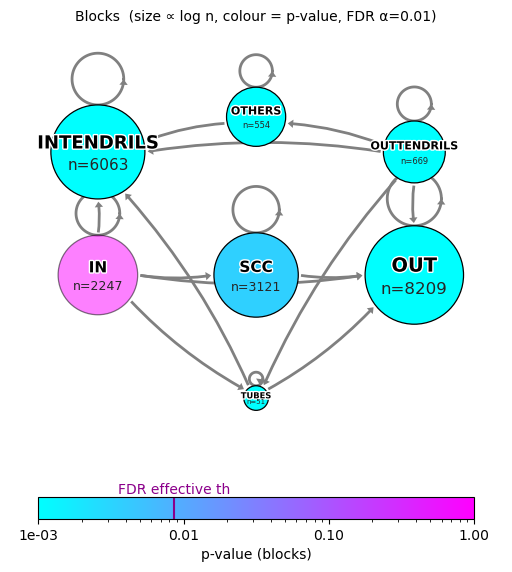

In [ ]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [ ]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [ ]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=3.60e-03, tail=right
OUT: p-value=0.00e+00, tail=left
IN: p-value=9.08e-01, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


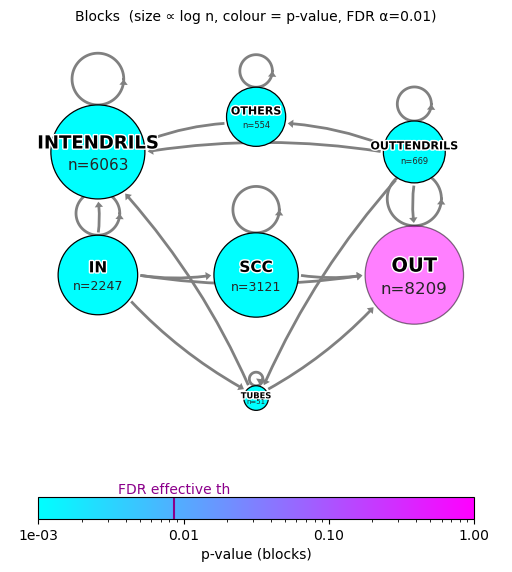

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

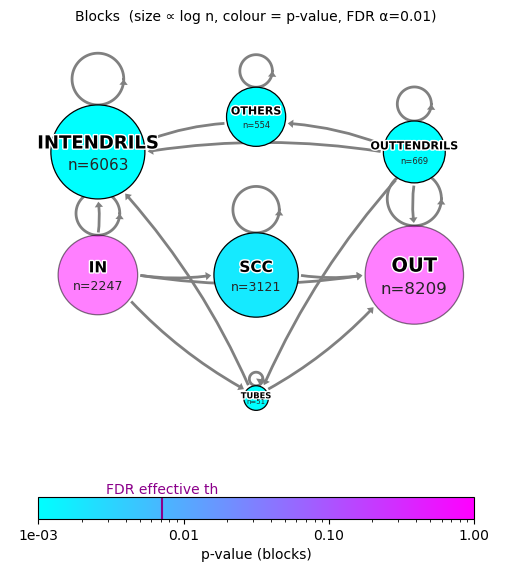

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

#### Distributions

In [ ]:
from scipy.stats import norm

In [ ]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

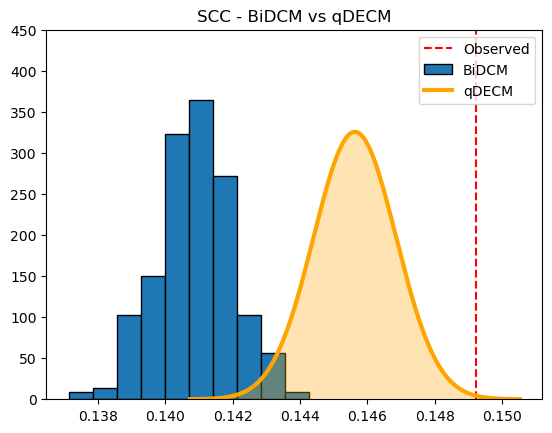

In [ ]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [ ]:
_block='IN'

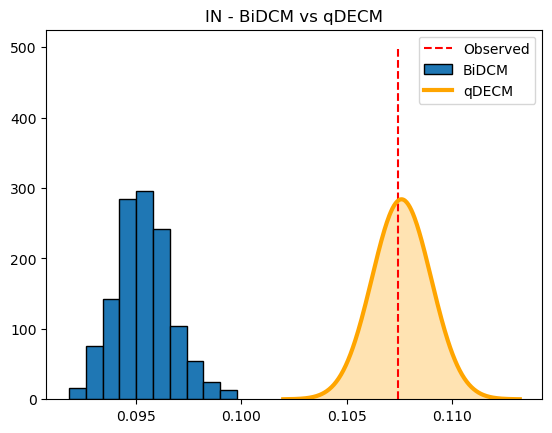

In [ ]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

## Quirinale

In [ ]:
labels_file=[file for file in os.listdir(GUARINO_FOLDER) if file.endswith('.pickle') and file.startswith('qui')][0]

In [ ]:
labels=pickle.load(open(GUARINO_FOLDER+labels_file, 'rb'))

In [ ]:
labels

{5: 'journalists & Media',
 2: 'M5S',
 0: 'journalists & IV & Azione & +Europa & Media',
 4: 'Lega & FDI',
 1: 'PD',
 3: 'Media & journalists',
 6: 'FI'}

### Right-wing

#### Bowties

In [ ]:
blocks=guarino2dict_blocks('ita_elections', 4)

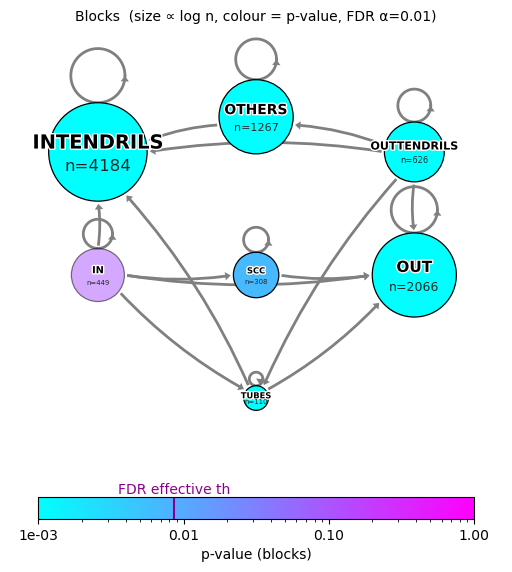

In [ ]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

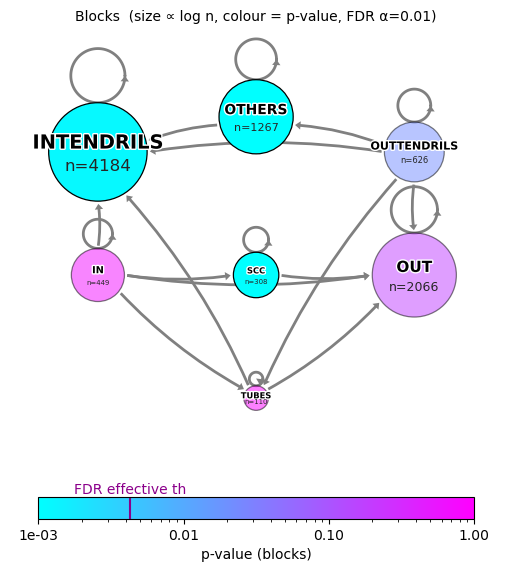

In [ ]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [ ]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=1.07e-01, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=6.67e-03, tail=right
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [ ]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUTTENDRILS: p-value=2.20e-02, tail=right
INTENDRILS: p-value=1.20e-03, tail=right
OUT: p-value=1.86e-01, tail=left
TUBES: p-value=9.30e-01, tail=right
OTHERS: p-value=0.00e+00, tail=right
IN: p-value=6.98e-01, tail=right
SCC: p-value=0.00e+00, tail=right


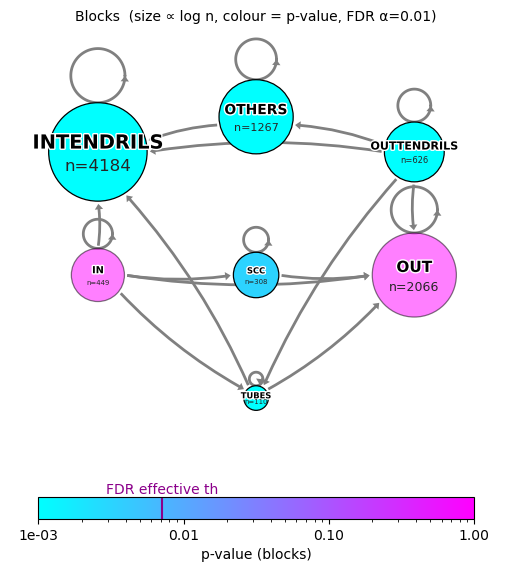

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

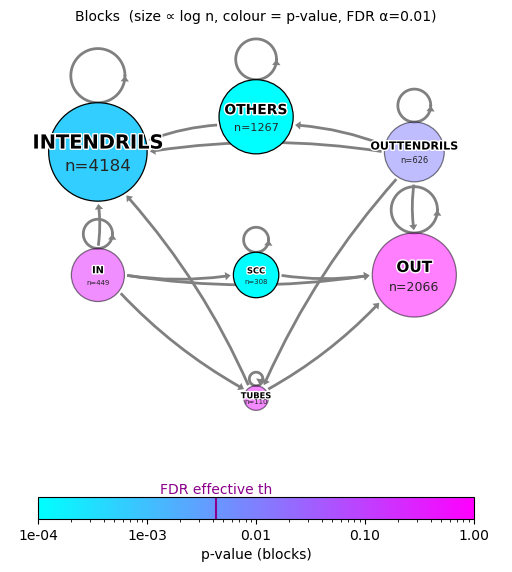

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

#### Distributions

In [ ]:
from scipy.stats import norm

In [ ]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

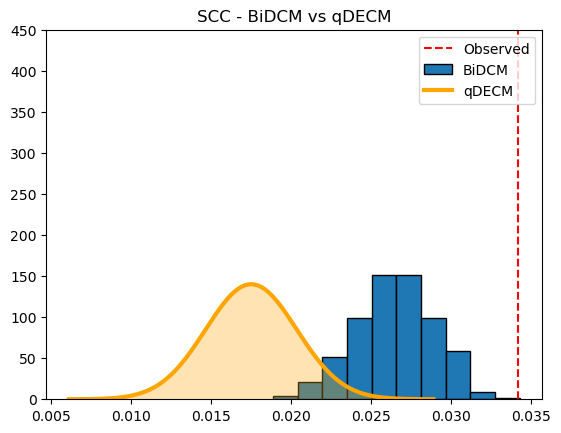

In [ ]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [ ]:
_block='OUTTENDRILS'

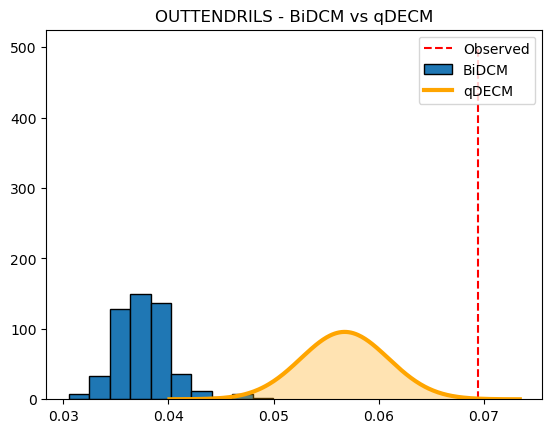

In [ ]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### Italia Viva & Azione

#### Bowties

In [ ]:
blocks=guarino2dict_blocks('ita_elections', 0)

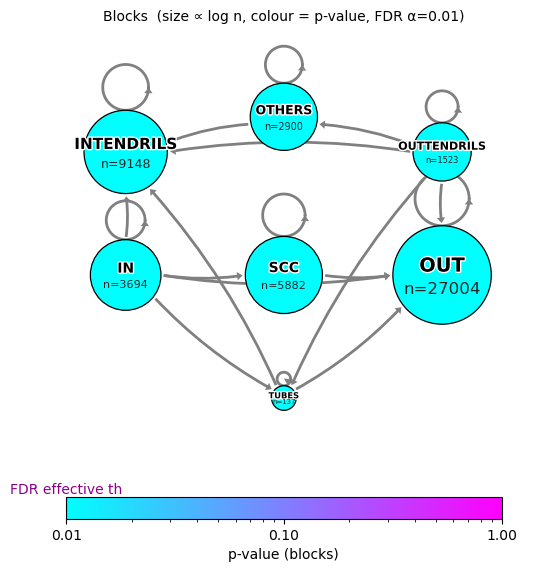

In [ ]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

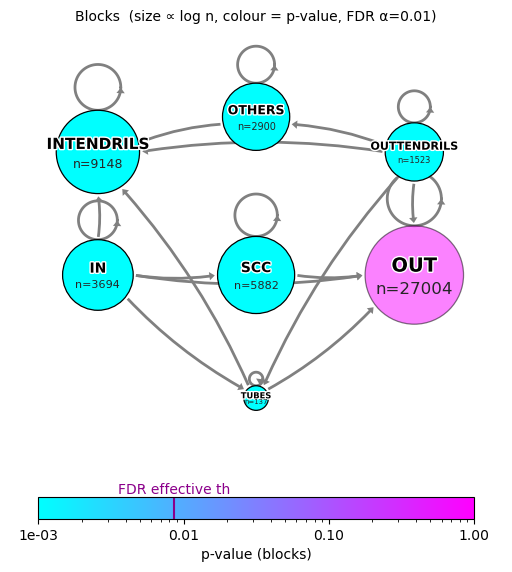

In [ ]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [ ]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [ ]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
OUT: p-value=8.41e-01, tail=left
SCC: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
IN: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


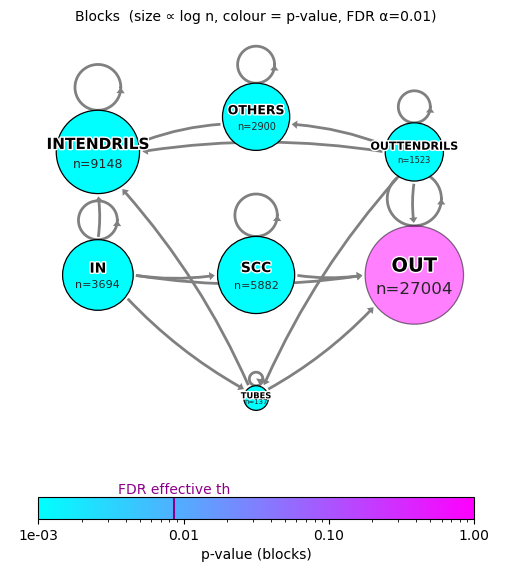

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

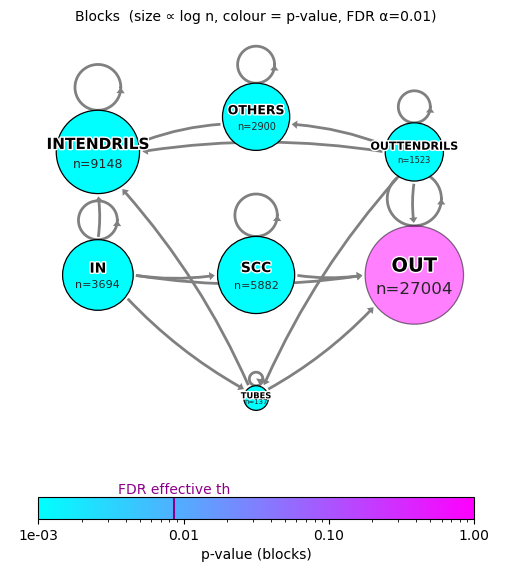

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

#### Distributions

In [ ]:
from scipy.stats import norm

In [ ]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

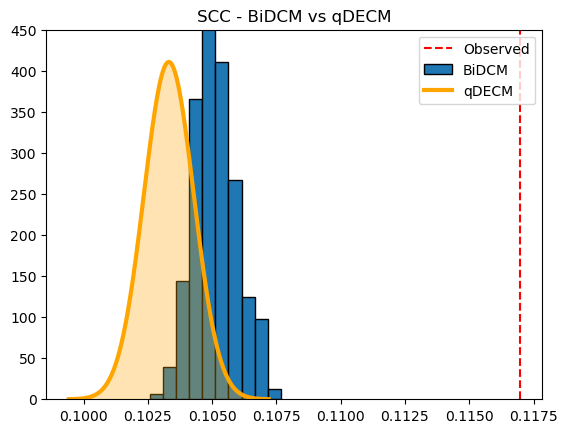

In [ ]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [ ]:
_block='OUT'

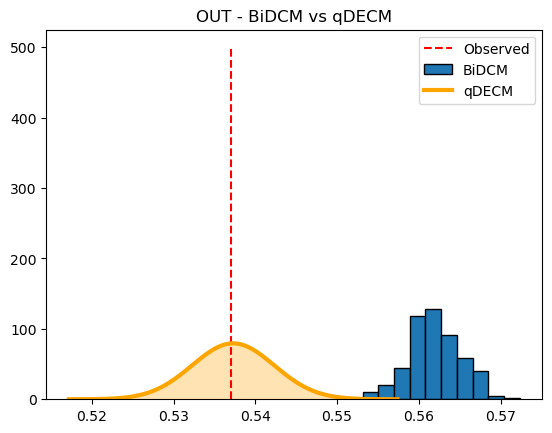

In [ ]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### M5S

#### Bowties

In [ ]:
blocks=guarino2dict_blocks('ita_elections', 2)

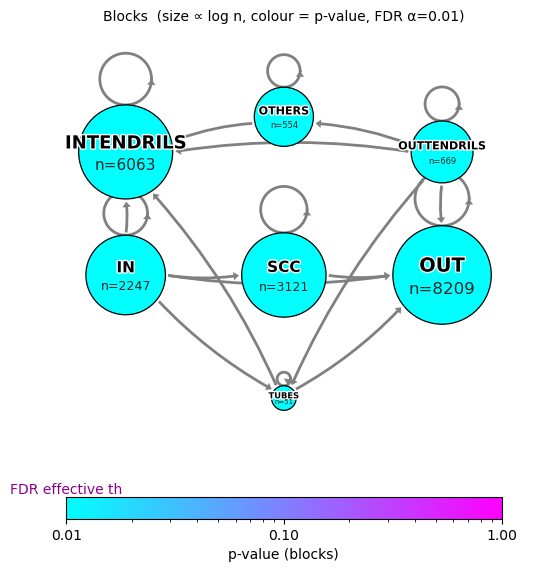

In [ ]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

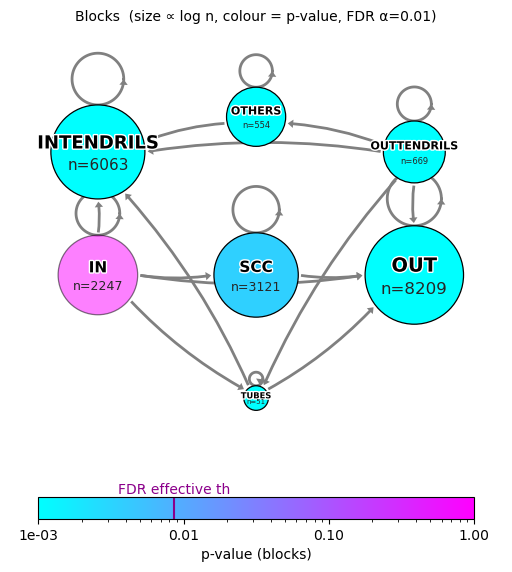

In [ ]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [ ]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=right
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [ ]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=3.60e-03, tail=right
OUT: p-value=0.00e+00, tail=left
IN: p-value=9.08e-01, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


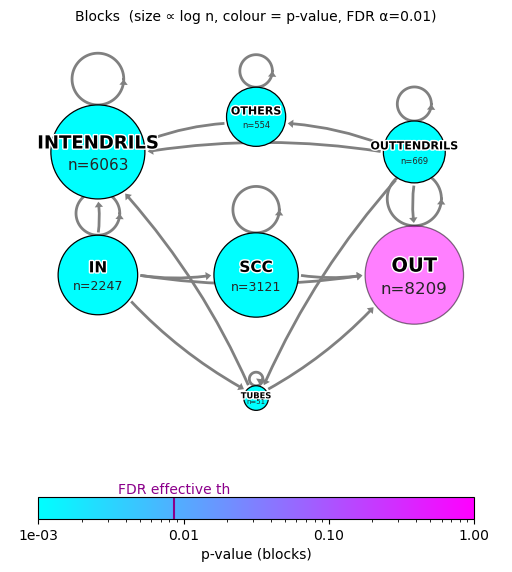

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

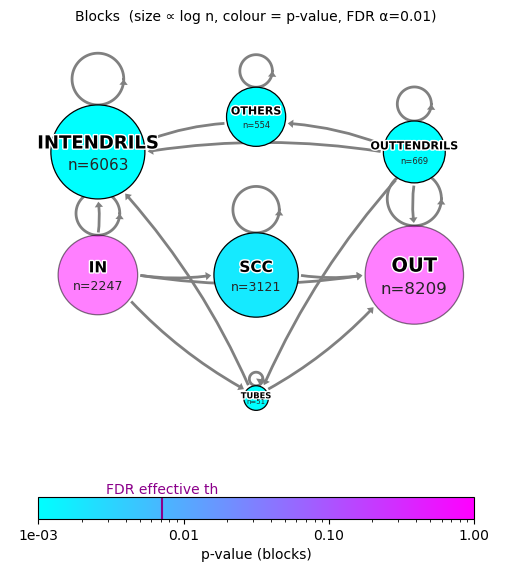

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

#### Distributions

In [ ]:
from scipy.stats import norm

In [ ]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

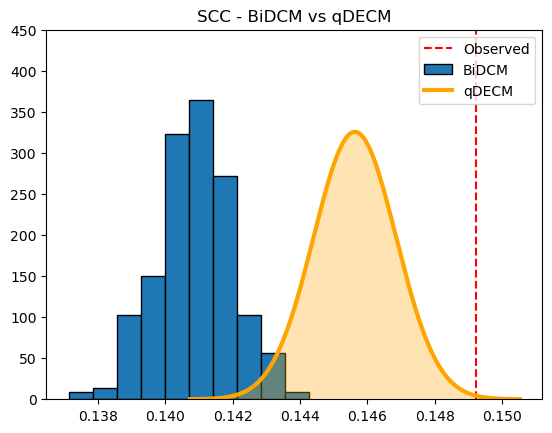

In [ ]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4.5*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [ ]:
_block='IN'

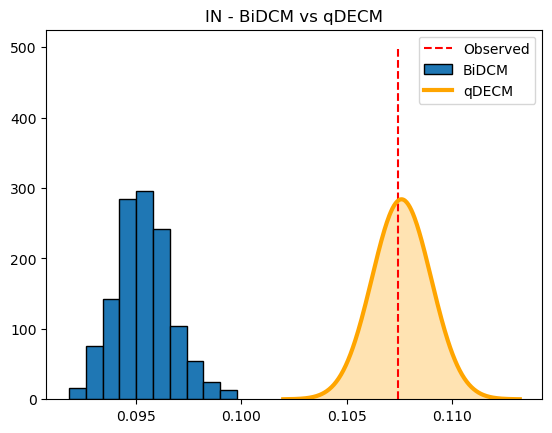

In [ ]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### PD

#### Bowties

In [ ]:
blocks=guarino2dict_blocks('ita_elections', 1)

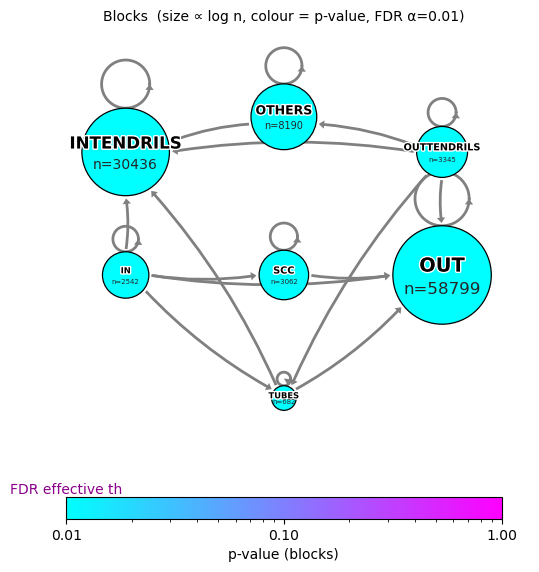

In [ ]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

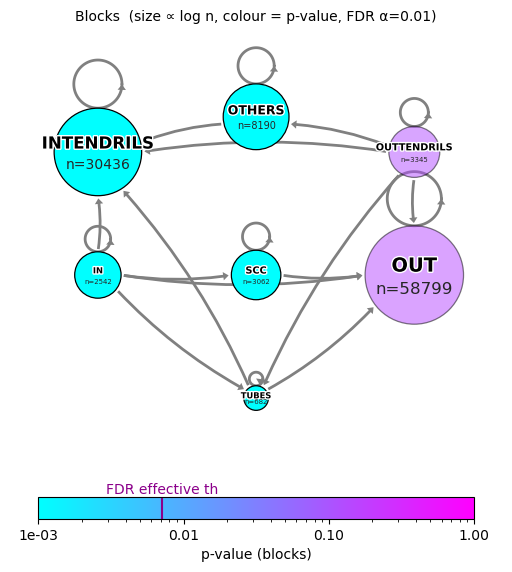

In [ ]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [ ]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=0.00e+00, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=left
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right


In [ ]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OUT: p-value=1.40e-01, tail=left
INTENDRILS: p-value=0.00e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
SCC: p-value=0.00e+00, tail=right
TUBES: p-value=0.00e+00, tail=right
OUTTENDRILS: p-value=1.22e-01, tail=left
IN: p-value=0.00e+00, tail=right


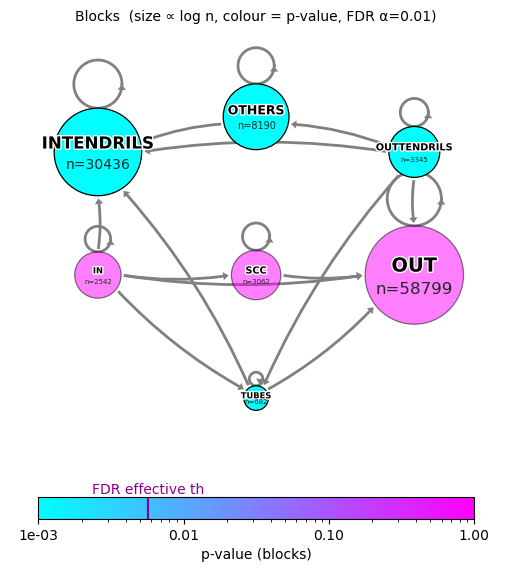

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

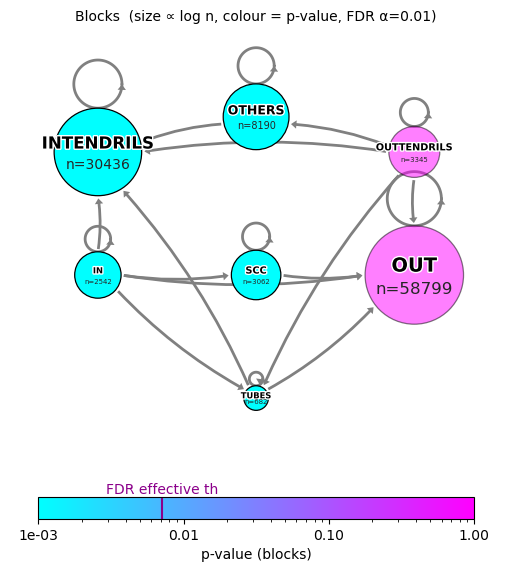

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

#### Distributions

In [ ]:
from scipy.stats import norm

In [ ]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

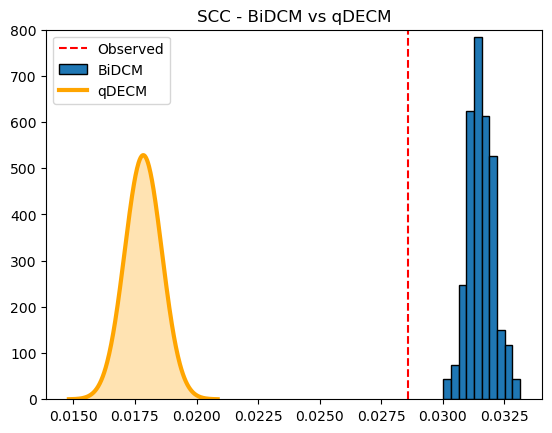

In [ ]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 8*10**2)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [ ]:
_block='OTHERS'

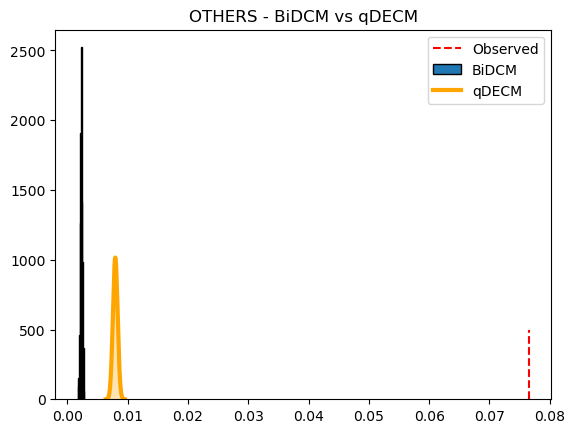

In [ ]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

### FI

#### Bowties

In [ ]:
blocks=guarino2dict_blocks('ita_elections', 6)

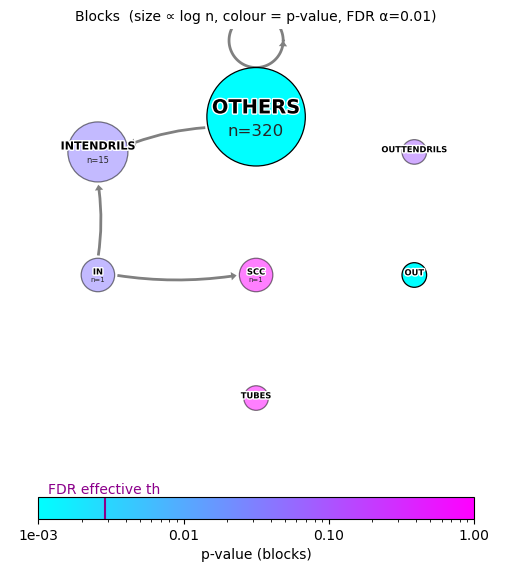

In [ ]:
plot_bowtie_blocks(blocks[0], blocks[2], 0.01)
plt.show()

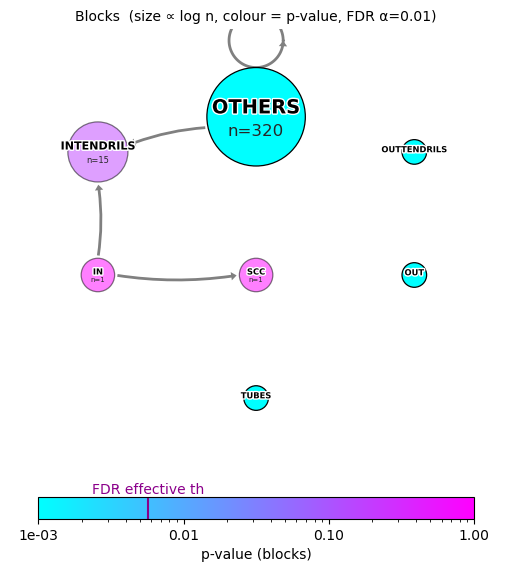

In [ ]:
plot_bowtie_blocks(blocks[1], blocks[2], 0.01)
plt.show()

They seem identical, but it is just a naive appeareance:

In [ ]:
for key, item in blocks[0].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

IN: p-value=4.00e-02, tail=right
INTENDRILS: p-value=4.00e-02, tail=right
SCC: p-value=1.95e+00, tail=right
OTHERS: p-value=0.00e+00, tail=right
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=8.67e-02, tail=left
TUBES: p-value=2.00e+00, tail=right


In [ ]:
for key, item in blocks[1].items():
    print(f"{key}: p-value={item['p_value']:.2e}, tail={item['tail']}")

OTHERS: p-value=0.00e+00, tail=right
INTENDRILS: p-value=1.75e-01, tail=left
SCC: p-value=1.00e+00, tail=left
IN: p-value=1.00e+00, tail=left
OUT: p-value=0.00e+00, tail=left
OUTTENDRILS: p-value=0.00e+00, tail=left
TUBES: p-value=0.00e+00, tail=left


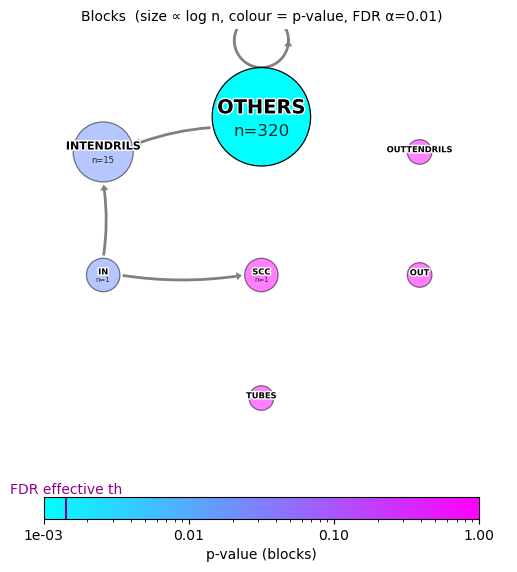

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[0]), blocks[2], 0.01)
plt.show()

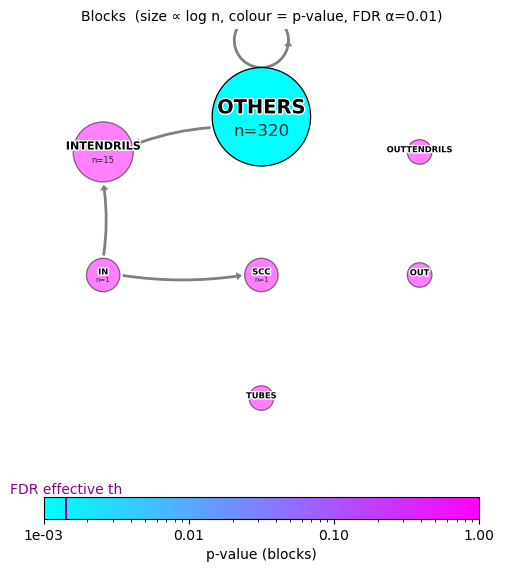

In [ ]:
plot_bowtie_blocks(right_tailer(blocks[1]), blocks[2], 0.01)
plt.show()

#### Distributions

In [ ]:
from scipy.stats import norm

In [ ]:
tot_nodes=0
for key in blocks[0].keys():
    tot_nodes+=blocks[0][key]['obs']

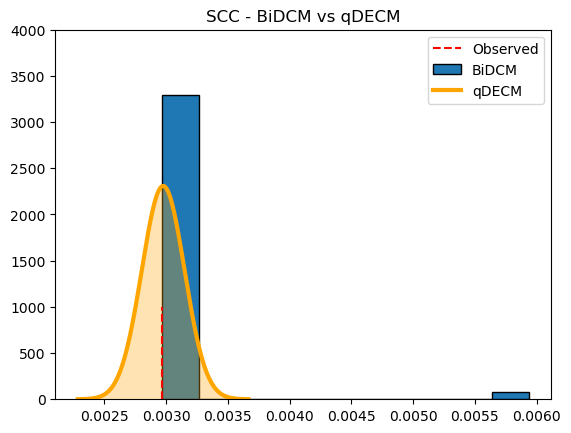

In [ ]:
mu = blocks[1]['SCC']['mean_sim']/tot_nodes
sig = blocks[1]['SCC']['std_sim']/tot_nodes

plt.vlines(blocks[0]['SCC']['obs']/tot_nodes, ymin=0, ymax=1000, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0]['SCC']['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4*10**3)
plt.title('SCC - BiDCM vs qDECM')
plt.legend()
plt.show()

In [ ]:
_block='OTHERS'

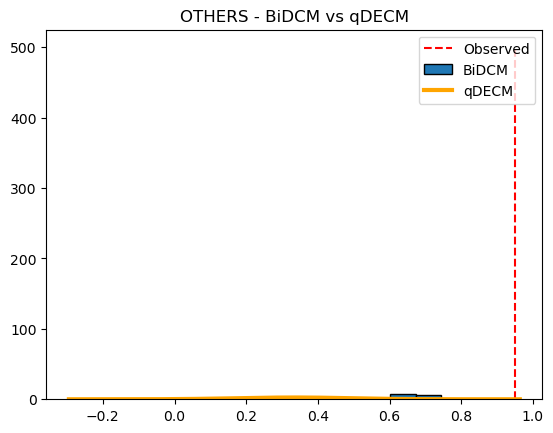

In [ ]:
mu = blocks[1][_block]['mean_sim']/tot_nodes
sig = blocks[1][_block]['std_sim']/tot_nodes

plt.vlines(blocks[0][_block]['obs']/tot_nodes, ymin=0, ymax=500, color='red', linestyle='--', label='Observed')
plt.hist(blocks[0][_block]['sample']/tot_nodes, edgecolor='black', density=True, label='BiDCM')
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
#plt.ylim(0, 1.8*10**3)
#plt.xscale('log')
plt.title(f'{_block} - BiDCM vs qDECM')
plt.legend()
plt.show()

# Summary and next steps 
Now data are ok and indeed the sizes of various blocks differ. Nevertheless there is still something strange: for instance, it seems that the values, both for BiDCM and qDECM are exactly the same for the SCC of PD for crisis and ita_elections, which is, at least, suspicious. So, checks to be performed:
1. check data: are those exactly the same? Does it depends on the origin of the data? As both my simulations and Stefano's take the same values, it could either be that I wrongly loaded the data for the plots or that, by mistake, the edgelist of Quirinale and Ita_elections are the same ones.
2. find a clear case in which blocks are really different in the "interesting" DiCos, i.e. Right-wing and Renzi's ones. 